In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow import keras
from tensorflow.keras import layers

I0000 00:00:1774510432.175980  108091 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774510432.248163  108091 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774510433.540732  108091 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
redwine = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv', sep=';')

In [ ]:
redwine.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
X, y = redwine.iloc[:,:-1], redwine.iloc[:,-1]

In [ ]:
X.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000


In [ ]:
y.describe()

count    1599.000000
mean        5.636023
std         0.807569
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         8.000000
Name: quality, dtype: float64

In [ ]:
y.value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

# y의 라벨인코딩 3~8 -> 0~5

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
np.unique(y_encoded)

array([0, 1, 2, 3, 4, 5])

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

In [ ]:
model = Sequential([
  Input(shape=(11,)),
  Dense(100,activation='sigmoid'),
  Dropout(0.2),
  Dense(200, activation='relu'),
  Dropout(0.4),
  Dense(50, activation='tanh'),
  Dropout(0.1),
  Dense(10, activation='softmax'),
])

I0000 00:00:1774511355.563570  108091 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [ ]:
X_train, X_test, y_train, y_test= train_test_split(X, y_encoded)

In [ ]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam', metrics=['accuracy'])

In [ ]:
history = model.fit(X_train, y_train, batch_size=200, epochs=300)

Epoch 1/300


I0000 00:00:1774511490.231743  111124 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_14633__.17


1/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.0000e+00 - loss: 7.7251

I0000 00:00:1774511491.898658  111124 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_14633__.17


6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 322ms/step - accuracy: 0.0075 - loss: 6.2582
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1218 - loss: 4.0071
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3161 - loss: 2.9771 
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3812 - loss: 2.0535 
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4087 - loss: 1.6763 
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4220 - loss: 1.4488 
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4362 - loss: 1.3308 
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4562 - loss: 1.2509 
Epoch 9/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4696 - loss: 1.2404 
Epoch 10/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4804 - loss: 1.2100 
Epoch 11/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4946 - loss: 1.1682 
Epoch 12/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4837 - loss: 1.1606 
E

In [ ]:
model.evaluate(X_test, y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6100 - loss: 0.9735


[0.9734739065170288, 0.6100000143051147]

In [ ]:
import numpy as np

num_classes = len(np.unique(y_train))

In [ ]:
model = Sequential([
    Input(shape=(11,)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32
)

Epoch 1/50


I0000 00:00:1774511784.774278  111123 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_27272__.15


21/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3045 - loss: 3.7332 

I0000 00:00:1774511786.786655  111122 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_27272__.15


38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - accuracy: 0.3837 - loss: 2.8875 - val_accuracy: 0.4650 - val_loss: 1.3462
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3778 - loss: 2.0922 - val_accuracy: 0.4475 - val_loss: 1.2055
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4078 - loss: 1.6863 - val_accuracy: 0.5025 - val_loss: 1.1853
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4329 - loss: 1.4668 - val_accuracy: 0.4925 - val_loss: 1.1847
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4245 - loss: 1.4338 - val_accuracy: 0.4675 - val_loss: 1.1783
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4270 - loss: 1.3567 - val_accuracy: 0.5050 - val_loss: 1.1629
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4354 - loss: 1.3604 - val_accuracy: 0.5125 - val_loss: 1.1494
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4595 - loss: 1.3279 - val_accuracy: 0.5200 - val_loss: 1.1332
Ep

In [ ]:
model.evaluate(X_test, y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5500 - loss: 1.0363 


[1.0363173484802246, 0.550000011920929]

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# X, y 준비
# X: 11개 feature
# y: quality

# 라벨 인코딩
le = LabelEncoder()
y_encoded = le.fit_transform(y)

num_classes = len(np.unique(y_encoded))

# stratify 꼭 권장
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 클래스 가중치
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weight_dict = dict(zip(classes, class_weights))

# 모델
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.1),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=600,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler],
    class_weight=class_weight_dict,
    verbose=1
)

test_loss, test_acc = model.evaluate(X_test_scaled, y_test)
print("Test Accuracy:", test_acc)

Epoch 1/600


I0000 00:00:1774512058.725638  111122 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_88494__.29


29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2550 - loss: 2.0113

I0000 00:00:1774512060.517841  111123 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_88494__.29


32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.2708 - loss: 2.1533 - val_accuracy: 0.3359 - val_loss: 1.6980 - learning_rate: 0.0010
Epoch 2/600
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2962 - loss: 1.6978 - val_accuracy: 0.3125 - val_loss: 1.6379 - learning_rate: 0.0010
Epoch 3/600
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3372 - loss: 1.4630 - val_accuracy: 0.3359 - val_loss: 1.5831 - learning_rate: 0.0010
Epoch 4/600
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3284 - loss: 1.3587 - val_accuracy: 0.3203 - val_loss: 1.5444 - learning_rate: 0.0010
Epoch 5/600
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3333 - loss: 1.2389 - val_accuracy: 0.3320 - val_loss: 1.5297 - learning_rate: 0.0010
Epoch 6/600
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3304 - loss: 1.1916 - val_accuracy: 0.3359 - val_loss: 1.5153 - learning_rate: 0.0010
Epoch 7/600
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3275 - loss: 1.1874 - val_accuracy: 0.35

In [ ]:
import matplotlib.pyplot as plt

required_vars = ["model", "history", "X_test_scaled", "y_test"]
missing_vars = [name for name in required_vars if name not in globals()]

if missing_vars:
    raise ValueError(
        "먼저 학습 셀을 실행해서 다음 변수를 만들어주세요: " + ", ".join(missing_vars)
    )

print("=" * 60)
print("MODEL SUMMARY")
print("=" * 60)
model.summary()

print("\n" + "=" * 60)
print("TEST METRICS")
print("=" * 60)
eval_results = model.evaluate(X_test_scaled, y_test, verbose=0)

if not isinstance(eval_results, (list, tuple)):
    eval_results = [eval_results]

for metric_name, metric_value in zip(model.metrics_names, eval_results):
    print(f"{metric_name}: {metric_value:.4f}")

history_dict = history.history
metric_candidates = ["accuracy", "acc", "bin_acc"]
metric_name = next((m for m in metric_candidates if m in history_dict), None)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_dict.get("loss", []), label="train_loss", linewidth=2)
if "val_loss" in history_dict:
    axes[0].plot(history_dict["val_loss"], label="val_loss", linewidth=2)
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

if metric_name is not None:
    axes[1].plot(history_dict[metric_name], label=f"train_{metric_name}", linewidth=2)
    val_metric_name = f"val_{metric_name}"
    if val_metric_name in history_dict:
        axes[1].plot(history_dict[val_metric_name], label=val_metric_name, linewidth=2)
    axes[1].set_title(metric_name.capitalize())
    axes[1].set_ylabel(metric_name.capitalize())
else:
    axes[1].text(0.5, 0.5, "accuracy history not found", ha="center", va="center", fontsize=12)
    axes[1].set_title("Accuracy")

axes[1].set_xlabel("Epoch")
axes[1].grid(True, alpha=0.3)
axes[1].legend() if axes[1].lines else None

plt.tight_layout()
plt.show()


In [ ]:
# =========================================================
# Wine Quality Deep Learning - Full Pipeline
# =========================================================

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Add, Activation
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical


# =========================================================
# 0. Reproducibility
# =========================================================
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# =========================================================
# 1. Load Data
#    - UCI winequality-red.csv / winequality-white.csv 기준
#    - 보통 세미콜론(;) 구분자라서 먼저 sep=';' 시도
# =========================================================
DATA_PATH = "winequality-red.csv"   # <- 네 파일명으로 바꿔줘

try:
    df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv', sep=';')
    if 'quality' not in df.columns:
        df = pd.read_csv(DATA_PATH)
except:
    df = pd.read_csv(DATA_PATH)

df.columns = df.columns.str.strip()

print("데이터 shape:", df.shape)
print("컬럼:", df.columns.tolist())
print("\nquality 분포:")
print(df['quality'].value_counts().sort_index())


# =========================================================
# 2. Feature Engineering
# =========================================================
def add_features(dataframe: pd.DataFrame) -> pd.DataFrame:
    df_ = dataframe.copy()

    # 1) alcohol / residual sugar
    if {'alcohol', 'residual sugar'}.issubset(df_.columns):
        df_['alcohol_sugar_ratio'] = df_['alcohol'] / (df_['residual sugar'] + 1.0)

    # 2) density * alcohol
    if {'density', 'alcohol'}.issubset(df_.columns):
        df_['density_alcohol_interaction'] = df_['density'] * df_['alcohol']

    # 3) total acidity
    if {'fixed acidity', 'volatile acidity', 'citric acid'}.issubset(df_.columns):
        df_['total_acidity'] = (
            df_['fixed acidity'] + df_['volatile acidity'] + df_['citric acid']
        )

    # 4) sulfur ratio
    if {'free sulfur dioxide', 'total sulfur dioxide'}.issubset(df_.columns):
        df_['sulfur_ratio'] = df_['free sulfur dioxide'] / (df_['total sulfur dioxide'] + 1.0)

    # 5) sulphates / chlorides
    if {'sulphates', 'chlorides'}.issubset(df_.columns):
        df_['sulphates_chlorides_ratio'] = df_['sulphates'] / (df_['chlorides'] + 1e-6)

    # 6) citric / fixed acidity
    if {'citric acid', 'fixed acidity'}.issubset(df_.columns):
        df_['citric_fixed_ratio'] = df_['citric acid'] / (df_['fixed acidity'] + 1e-6)

    # 7) alcohol * sulphates
    if {'alcohol', 'sulphates'}.issubset(df_.columns):
        df_['alcohol_sulphates_interaction'] = df_['alcohol'] * df_['sulphates']

    # 8) acidity balance
    if {'pH', 'fixed acidity'}.issubset(df_.columns):
        df_['acidity_ph_interaction'] = df_['fixed acidity'] / (df_['pH'] + 1e-6)

    return df_


df = add_features(df)

X = df.drop(columns=['quality']).copy()
y = df['quality'].copy()

print("\nFeature engineering 후 X shape:", X.shape)


# =========================================================
# 3. Label Encoding
#    - quality가 3,4,5,6,7,8 형태여도
#      0,1,2,... 로 인코딩해서 softmax에 맞춤
# =========================================================
le = LabelEncoder()
y_encoded = le.fit_transform(y)

num_classes = len(np.unique(y_encoded))
input_dim = X.shape[1]

print("원래 quality 클래스:", list(le.classes_))
print("인코딩 후 클래스 개수:", num_classes)


# =========================================================
# 4. Train / Test Split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=SEED,
    stratify=y_encoded
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = np.array(y_train)
y_test = np.array(y_test)

print("\nTrain shape:", X_train.shape, y_train.shape)
print("Test shape :", X_test.shape, y_test.shape)


# =========================================================
# 5. Scaler
#    - train에만 fit
# =========================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)


# =========================================================
# 6. Residual Block / Model Builder
# =========================================================
def residual_block(x, units, dropout_rate=0.15, l2_reg=1e-4):
    shortcut = x

    # 차원 안 맞으면 projection
    if x.shape[-1] != units:
        shortcut = Dense(units, kernel_regularizer=l2(l2_reg))(shortcut)
        shortcut = BatchNormalization()(shortcut)

    out = Dense(units, activation='relu', kernel_regularizer=l2(l2_reg))(x)
    out = BatchNormalization()(out)
    out = Dropout(dropout_rate)(out)

    out = Dense(units, kernel_regularizer=l2(l2_reg))(out)
    out = BatchNormalization()(out)

    out = Add()([shortcut, out])
    out = Activation('relu')(out)
    return out


def build_model(input_dim, num_classes):
    inputs = Input(shape=(input_dim,))

    x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.20)(x)

    x = residual_block(x, 128, dropout_rate=0.15, l2_reg=1e-4)
    x = residual_block(x, 128, dropout_rate=0.15, l2_reg=1e-4)
    x = residual_block(x, 128, dropout_rate=0.15, l2_reg=1e-4)

    x = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.15)(x)

    x = Dense(32, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.10)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03),
        metrics=['accuracy']
    )

    return model


# =========================================================
# 7. Stratified K-Fold Ensemble
# =========================================================
N_SPLITS = 5
BATCH_SIZE = 16
EPOCHS = 300

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_pred = np.zeros((len(X_train_scaled), num_classes), dtype=np.float32)
test_pred_folds = []
fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train), start=1):
    print(f"\n================ Fold {fold} / {N_SPLITS} ================")

    X_tr, X_val = X_train_scaled[tr_idx], X_train_scaled[val_idx]
    y_tr_int, y_val_int = y_train[tr_idx], y_train[val_idx]

    y_tr = to_categorical(y_tr_int, num_classes=num_classes)
    y_val = to_categorical(y_val_int, num_classes=num_classes)

    # 클래스 불균형 보정용 sample weight
    classes = np.unique(y_tr_int)
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=classes,
        y=y_tr_int
    )
    class_weight_map = dict(zip(classes, class_weights))
    sample_weights = np.array([class_weight_map[c] for c in y_tr_int], dtype=np.float32)

    model = build_model(input_dim=input_dim, num_classes=num_classes)

    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=25,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=8,
            min_lr=1e-6,
            verbose=1
        )
    ]

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        sample_weight=sample_weights,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=0
    )

    # validation 예측
    val_probs = model.predict(X_val, verbose=0)
    val_pred = np.argmax(val_probs, axis=1)
    val_acc = accuracy_score(y_val_int, val_pred)
    fold_scores.append(val_acc)

    print(f"Fold {fold} Accuracy: {val_acc:.4f}")

    oof_pred[val_idx] = val_probs

    # test 예측 저장
    test_probs = model.predict(X_test_scaled, verbose=0)
    test_pred_folds.append(test_probs)


# =========================================================
# 8. OOF / Ensemble Evaluation
# =========================================================
oof_pred_labels = np.argmax(oof_pred, axis=1)
oof_acc = accuracy_score(y_train, oof_pred_labels)

print("\n======================================")
print("Fold Accuracy 목록:", [round(s, 4) for s in fold_scores])
print("Mean Fold Accuracy:", round(np.mean(fold_scores), 4))
print("OOF Accuracy      :", round(oof_acc, 4))
print("======================================")

# Fold별 test 예측 평균
test_pred_mean = np.mean(test_pred_folds, axis=0)
test_pred_labels = np.argmax(test_pred_mean, axis=1)

test_acc = accuracy_score(y_test, test_pred_labels)
print("\nEnsemble Test Accuracy:", round(test_acc, 4))


# =========================================================
# 9. Detailed Report
# =========================================================
# 원래 quality 값으로 복원
y_test_original = le.inverse_transform(y_test)
y_pred_original = le.inverse_transform(test_pred_labels)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_original, y_pred_original))

print("\nClassification Report:")
print(
    classification_report(
        y_test_original,
        y_pred_original,
        digits=4
    )
)


# =========================================================
# 10. Single Sample Prediction Example
# =========================================================
# 예시: 첫 번째 테스트 데이터 예측
sample_idx = 0
sample_probs = test_pred_mean[sample_idx]
sample_pred_encoded = np.argmax(sample_probs)
sample_pred_quality = le.inverse_transform([sample_pred_encoded])[0]

print("\n예시 1건 예측")
print("실제 quality :", y_test_original[sample_idx])
print("예측 quality :", sample_pred_quality)
print("클래스별 확률 :", np.round(sample_probs, 4))


# =========================================================
# 11. 필요하면 저장
# =========================================================
# scaler, label encoder, 최종 test_pred_mean 등 저장하고 싶으면 아래 사용
# import joblib
# joblib.dump(scaler, "wine_scaler.pkl")
# joblib.dump(le, "wine_label_encoder.pkl")

데이터 shape: (1599, 12)
컬럼: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

quality 분포:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Feature engineering 후 X shape: (1599, 19)
원래 quality 클래스: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
인코딩 후 클래스 개수: 6

Train shape: (1279, 19) (1279,)
Test shape : (320, 19) (320,)

================ Fold 1 / 5 ================


I0000 00:00:1774512524.076724  111121 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_105571__.88
I0000 00:00:1774512530.118710  111124 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_105571__.88



Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 39: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 47: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 55: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 56: early stopping
Restoring model weights from the end of the best epoch: 31.
Fold 1 Accuracy: 0.4727

================ Fold 2 / 5 ================


I0000 00:00:1774512559.766318  111122 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_136163__.88
I0000 00:00:1774512563.332127  111121 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_136163__.88



Epoch 34: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 42: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 50: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 51: early stopping
Restoring model weights from the end of the best epoch: 26.
Fold 2 Accuracy: 0.4844

================ Fold 3 / 5 ================


...


Epoch 38: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 50: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 58: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 66: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 67: early stopping
Restoring model weights from the end of the best epoch: 42.
Fold 3 Accuracy: 0.5117

================ Fold 4 / 5 ================


I0000 00:00:1774512620.395883  111124 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_199768__.88
I0000 00:00:1774512623.851782  111125 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_199768__.88



Epoch 33: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 41: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 49: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 50: early stopping
Restoring model weights from the end of the best epoch: 25.
Fold 4 Accuracy: 0.5039

================ Fold 5 / 5 ================


I0000 00:00:1774512647.811812  111121 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_227724__.72



Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 42: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 50: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 61: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 73: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 86: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 94: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.

Epoch 102: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.
Epoch 103: early stopping
Restoring model weights from the end of the best epoch: 78.
Fold 5 Accuracy: 0.5059

Fold Accuracy 목록: [0.4727, 0.4844, 0.5117, 0.5039, 0.5059]
Mean Fold Accuracy: 0.4957
OOF Accuracy      : 0.4957

Ensemble Test Accuracy: 0.5344

Confusion Matrix:
[[ 0  1  1  0  0  0]
 [ 1  4  5  1  0  0]
 [ 2 11 83 36  4  0]
 [ 2  4 33 54 32  3]
 [ 0  0  0  8 30

In [ ]:
# =========================================================
# Wine Quality Deep Learning - Regression to Class
# =========================================================

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_absolute_error, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Add, Activation
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2


# =========================================================
# 0. Seed
# =========================================================
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# =========================================================
# 1. Load Data
# =========================================================
DATA_PATH = "winequality-red.csv"   # 파일명 바꿔도 됨

try:
    df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv', sep=';')
    if 'quality' not in df.columns:
        df = pd.read_csv(DATA_PATH)
except:
    df = pd.read_csv(DATA_PATH)

df.columns = df.columns.str.strip()

print("데이터 shape:", df.shape)
print(df['quality'].value_counts().sort_index())


# =========================================================
# 2. Feature Engineering
# =========================================================
def add_features(dataframe):
    df_ = dataframe.copy()

    if {'alcohol', 'residual sugar'}.issubset(df_.columns):
        df_['alcohol_sugar_ratio'] = df_['alcohol'] / (df_['residual sugar'] + 1.0)

    if {'density', 'alcohol'}.issubset(df_.columns):
        df_['density_alcohol_interaction'] = df_['density'] * df_['alcohol']

    if {'fixed acidity', 'volatile acidity', 'citric acid'}.issubset(df_.columns):
        df_['total_acidity'] = (
            df_['fixed acidity'] + df_['volatile acidity'] + df_['citric acid']
        )

    if {'free sulfur dioxide', 'total sulfur dioxide'}.issubset(df_.columns):
        df_['sulfur_ratio'] = df_['free sulfur dioxide'] / (df_['total sulfur dioxide'] + 1.0)

    if {'sulphates', 'chlorides'}.issubset(df_.columns):
        df_['sulphates_chlorides_ratio'] = df_['sulphates'] / (df_['chlorides'] + 1e-6)

    if {'citric acid', 'fixed acidity'}.issubset(df_.columns):
        df_['citric_fixed_ratio'] = df_['citric acid'] / (df_['fixed acidity'] + 1e-6)

    if {'alcohol', 'sulphates'}.issubset(df_.columns):
        df_['alcohol_sulphates_interaction'] = df_['alcohol'] * df_['sulphates']

    if {'pH', 'fixed acidity'}.issubset(df_.columns):
        df_['acidity_ph_interaction'] = df_['fixed acidity'] / (df_['pH'] + 1e-6)

    return df_


df = add_features(df)

X = df.drop(columns=['quality']).copy()
y = df['quality'].astype(np.float32).values

min_quality = int(df['quality'].min())
max_quality = int(df['quality'].max())

print("quality 범위:", min_quality, "~", max_quality)
print("X shape:", X.shape)


# =========================================================
# 3. Train/Test Split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y.astype(int)
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)


# =========================================================
# 4. Model
# =========================================================
def residual_block(x, units, dropout_rate=0.10, l2_reg=1e-4):
    shortcut = x

    if x.shape[-1] != units:
        shortcut = Dense(units, kernel_regularizer=l2(l2_reg))(shortcut)
        shortcut = BatchNormalization()(shortcut)

    out = Dense(units, activation='relu', kernel_regularizer=l2(l2_reg))(x)
    out = BatchNormalization()(out)
    out = Dropout(dropout_rate)(out)

    out = Dense(units, kernel_regularizer=l2(l2_reg))(out)
    out = BatchNormalization()(out)

    out = Add()([shortcut, out])
    out = Activation('relu')(out)
    return out


def build_regression_model(input_dim):
    inputs = Input(shape=(input_dim,))

    x = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.15)(x)

    x = residual_block(x, 256, dropout_rate=0.10)
    x = residual_block(x, 256, dropout_rate=0.10)

    x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.10)(x)

    x = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.05)(x)

    outputs = Dense(1, activation='linear')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=8e-4),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=['mae']
    )
    return model


# =========================================================
# 5. K-Fold Ensemble
# =========================================================
N_SPLITS = 7
BATCH_SIZE = 16
EPOCHS = 400

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_pred = np.zeros(len(X_train_scaled), dtype=np.float32)
test_preds = []
fold_accs = []
fold_maes = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_scaled), start=1):
    print(f"\n================ Fold {fold}/{N_SPLITS} ================")

    X_tr, X_val = X_train_scaled[tr_idx], X_train_scaled[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    model = build_regression_model(X_train_scaled.shape[1])

    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=35,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            min_lr=1e-6,
            verbose=1
        )
    ]

    model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=0
    )

    val_pred_cont = model.predict(X_val, verbose=0).reshape(-1)
    val_pred_cls = np.clip(np.rint(val_pred_cont), min_quality, max_quality).astype(int)

    val_true_cls = y_val.astype(int)

    val_acc = accuracy_score(val_true_cls, val_pred_cls)
    val_mae = mean_absolute_error(y_val, val_pred_cont)

    print(f"Fold {fold} Accuracy: {val_acc:.4f}")
    print(f"Fold {fold} MAE     : {val_mae:.4f}")

    fold_accs.append(val_acc)
    fold_maes.append(val_mae)

    oof_pred[val_idx] = val_pred_cont

    test_pred_cont = model.predict(X_test_scaled, verbose=0).reshape(-1)
    test_preds.append(test_pred_cont)


# =========================================================
# 6. OOF / Test Evaluation
# =========================================================
oof_pred_cls = np.clip(np.rint(oof_pred), min_quality, max_quality).astype(int)
y_train_cls = y_train.astype(int)

oof_acc = accuracy_score(y_train_cls, oof_pred_cls)
oof_mae = mean_absolute_error(y_train, oof_pred)

print("\n======================================")
print("Fold Accuracy 목록:", [round(x, 4) for x in fold_accs])
print("Mean Fold Accuracy:", round(np.mean(fold_accs), 4))
print("OOF Accuracy      :", round(oof_acc, 4))
print("======================================")

print("\nFold MAE 목록:", [round(x, 4) for x in fold_maes])
print("Mean Fold MAE:", round(np.mean(fold_maes), 4))
print("OOF MAE      :", round(oof_mae, 4))

test_pred_mean = np.mean(test_preds, axis=0)
test_pred_cls = np.clip(np.rint(test_pred_mean), min_quality, max_quality).astype(int)
y_test_cls = y_test.astype(int)

test_acc = accuracy_score(y_test_cls, test_pred_cls)
test_mae = mean_absolute_error(y_test, test_pred_mean)

print("\nEnsemble Test Accuracy:", round(test_acc, 4))
print("Ensemble Test MAE     :", round(test_mae, 4))


# =========================================================
# 7. Extra Metrics
# =========================================================
within_1 = np.mean(np.abs(test_pred_cls - y_test_cls) <= 1)
print("±1 허용 정확도       :", round(within_1, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_cls, test_pred_cls))

print("\nClassification Report:")
print(classification_report(y_test_cls, test_pred_cls, digits=4))


# =========================================================
# 8. Sample Predictions
# =========================================================
print("\n예측 샘플 10개")
for i in range(min(10, len(y_test_cls))):
    print(
        f"[{i}] 실제={y_test_cls[i]} | 예측연속값={test_pred_mean[i]:.3f} | 최종예측={test_pred_cls[i]}"
    )

데이터 shape: (1599, 12)
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64
quality 범위: 3 ~ 8
X shape: (1599, 19)

================ Fold 1/7 ================


I0000 00:00:1774512946.324381  111123 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_274427__.63
I0000 00:00:1774512951.106428  111126 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_274427__.63



Epoch 17: ReduceLROnPlateau reducing learning rate to 0.00039999998989515007.

Epoch 39: ReduceLROnPlateau reducing learning rate to 0.00019999999494757503.

Epoch 49: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-05.

Epoch 59: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
Epoch 64: early stopping
Restoring model weights from the end of the best epoch: 29.
Fold 1 Accuracy: 0.5792
Fold 1 MAE     : 0.5583

================ Fold 2/7 ================


I0000 00:00:1774512982.506783  111125 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_305781__.63
I0000 00:00:1774512985.487990  111125 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_305781__.63



Epoch 19: ReduceLROnPlateau reducing learning rate to 0.00039999998989515007.

Epoch 44: ReduceLROnPlateau reducing learning rate to 0.00019999999494757503.

Epoch 59: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-05.

Epoch 74: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 84: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 94: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
Epoch 99: early stopping
Restoring model weights from the end of the best epoch: 64.
Fold 2 Accuracy: 0.5792
Fold 2 MAE     : 0.5052

================ Fold 3/7 ================


...


Epoch 30: ReduceLROnPlateau reducing learning rate to 0.00039999998989515007.

Epoch 45: ReduceLROnPlateau reducing learning rate to 0.00019999999494757503.

Epoch 68: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-05.

Epoch 78: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 88: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 100: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.

Epoch 110: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-06.

Epoch 120: ReduceLROnPlateau reducing learning rate to 3.12499992105586e-06.
Epoch 125: early stopping
Restoring model weights from the end of the best epoch: 90.
Fold 5 Accuracy: 0.6284
Fold 5 MAE     : 0.5182

================ Fold 6/7 ================


I0000 00:00:1774513125.609268  111126 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_458635__.63
I0000 00:00:1774513128.608444  111126 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_458635__.63



Epoch 17: ReduceLROnPlateau reducing learning rate to 0.00039999998989515007.

Epoch 38: ReduceLROnPlateau reducing learning rate to 0.00019999999494757503.

Epoch 48: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-05.

Epoch 72: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 82: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 92: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
Epoch 97: early stopping
Restoring model weights from the end of the best epoch: 62.
Fold 6 Accuracy: 0.5879
Fold 6 MAE     : 0.5345

================ Fold 7/7 ================


I0000 00:00:1774513168.698633  111122 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_501903__.63
I0000 00:00:1774513171.758678  111122 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_501903__.63



Epoch 16: ReduceLROnPlateau reducing learning rate to 0.00039999998989515007.

Epoch 37: ReduceLROnPlateau reducing learning rate to 0.00019999999494757503.

Epoch 47: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-05.

Epoch 57: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
Epoch 62: early stopping
Restoring model weights from the end of the best epoch: 27.
Fold 7 Accuracy: 0.6484
Fold 7 MAE     : 0.4981

Fold Accuracy 목록: [0.5792, 0.5792, 0.5792, 0.5082, 0.6284, 0.5879, 0.6484]
Mean Fold Accuracy: 0.5872
OOF Accuracy      : 0.5872

Fold MAE 목록: [0.5583, 0.5052, 0.5166, 0.5717, 0.5182, 0.5345, 0.4981]
Mean Fold MAE: 0.5289
OOF MAE      : 0.529

Ensemble Test Accuracy: 0.6188
Ensemble Test MAE     : 0.4739
±1 허용 정확도       : 0.9594

Confusion Matrix:
[[  0   0   2   0   0   0]
 [  0   0   8   3   0   0]
 [  0   0 100  33   3   0]
 [  0   0  39  83   6   0]
 [  0   0   2  21  15   2]
 [  0   0   0   3   0   0]]

Classification Report:
              p

In [ ]:
import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# y_train, y_test가 float이면 int로 변환
y_train_cls = y_train.astype(int)
y_test_cls = y_test.astype(int)

# 실제 클래스들
classes = np.sort(np.unique(y_train_cls))
print("classes:", classes)

# 초기 threshold: 클래스 중간값
init_thresholds = np.array([(classes[i] + classes[i+1]) / 2 for i in range(len(classes)-1)], dtype=float)
print("initial thresholds:", init_thresholds)

def apply_thresholds(preds, thresholds, classes):
    thresholds = np.sort(thresholds)
    idx = np.digitize(preds, thresholds)
    return classes[idx]

def objective(thresholds):
    pred_cls = apply_thresholds(oof_pred, thresholds, classes)
    return -accuracy_score(y_train_cls, pred_cls)

# threshold 최적화
result = minimize(
    objective,
    x0=init_thresholds,
    method="Nelder-Mead",
    options={"maxiter": 5000, "disp": True}
)

best_thresholds = np.sort(result.x)
print("best thresholds:", best_thresholds)

# OOF 평가
oof_pred_cls_opt = apply_thresholds(oof_pred, best_thresholds, classes)
oof_acc_opt = accuracy_score(y_train_cls, oof_pred_cls_opt)

print("\n======================================")
print("Optimized OOF Accuracy:", round(oof_acc_opt, 4))
print("======================================")

# Test 평가
test_pred_cls_opt = apply_thresholds(test_pred_mean, best_thresholds, classes)
test_acc_opt = accuracy_score(y_test_cls, test_pred_cls_opt)

print("\nOptimized Test Accuracy:", round(test_acc_opt, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_cls, test_pred_cls_opt))

print("\nClassification Report:")
print(classification_report(y_test_cls, test_pred_cls_opt, digits=4))

print("\n샘플 10개 비교")
for i in range(min(10, len(y_test_cls))):
    print(
        f"[{i}] 실제={y_test_cls[i]} | 연속예측={test_pred_mean[i]:.3f} | "
        f"기존반올림={int(np.clip(np.rint(test_pred_mean[i]), classes.min(), classes.max()))} | "
        f"threshold적용={test_pred_cls_opt[i]}"
    )

classes: [3 4 5 6 7 8]
initial thresholds: [3.5 4.5 5.5 6.5 7.5]
Optimization terminated successfully.
         Current function value: -0.602033
         Iterations: 45
         Function evaluations: 130
best thresholds: [3.66716734 4.28095365 5.56877954 6.42079215 7.96130225]

Optimized OOF Accuracy: 0.602

Optimized Test Accuracy: 0.6375

Confusion Matrix:
[[  0   0   2   0   0   0]
 [  0   0   9   2   0   0]
 [  0   0 108  25   3   0]
 [  0   0  44  78   6   0]
 [  0   0   3  19  18   0]
 [  0   0   0   2   1   0]]

Classification Report:
              precision    recall  f1-score   support

           3     0.0000    0.0000    0.0000         2
           4     0.0000    0.0000    0.0000        11
           5     0.6506    0.7941    0.7152       136
           6     0.6190    0.6094    0.6142       128
           7     0.6429    0.4500    0.5294        40
           8     0.0000    0.0000    0.0000         3

    accuracy                         0.6375       320
   macro avg     

In [1]:
# =========================================================
# Wine Quality - Deep Learning Ordinal Classification
# =========================================================

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Add, Activation
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2


# =========================================================
# 0. Seed
# =========================================================
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# =========================================================
# 1. Load Data
# =========================================================
DATA_PATH = "winequality-red.csv"   # 파일명 맞게 수정

try:
    df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv', sep=';')
    if 'quality' not in df.columns:
        df = pd.read_csv(DATA_PATH)
except:
    df = pd.read_csv(DATA_PATH)

df.columns = df.columns.str.strip()

print("데이터 shape:", df.shape)
print("\nquality 분포:")
print(df["quality"].value_counts().sort_index())


# =========================================================
# 2. Feature Engineering
# =========================================================
def add_features(dataframe):
    df_ = dataframe.copy()

    if {'alcohol', 'residual sugar'}.issubset(df_.columns):
        df_['alcohol_sugar_ratio'] = df_['alcohol'] / (df_['residual sugar'] + 1.0)

    if {'density', 'alcohol'}.issubset(df_.columns):
        df_['density_alcohol_interaction'] = df_['density'] * df_['alcohol']

    if {'fixed acidity', 'volatile acidity', 'citric acid'}.issubset(df_.columns):
        df_['total_acidity'] = (
            df_['fixed acidity'] + df_['volatile acidity'] + df_['citric acid']
        )

    if {'free sulfur dioxide', 'total sulfur dioxide'}.issubset(df_.columns):
        df_['sulfur_ratio'] = df_['free sulfur dioxide'] / (df_['total sulfur dioxide'] + 1.0)

    if {'sulphates', 'chlorides'}.issubset(df_.columns):
        df_['sulphates_chlorides_ratio'] = df_['sulphates'] / (df_['chlorides'] + 1e-6)

    if {'citric acid', 'fixed acidity'}.issubset(df_.columns):
        df_['citric_fixed_ratio'] = df_['citric acid'] / (df_['fixed acidity'] + 1e-6)

    if {'alcohol', 'sulphates'}.issubset(df_.columns):
        df_['alcohol_sulphates_interaction'] = df_['alcohol'] * df_['sulphates']

    if {'pH', 'fixed acidity'}.issubset(df_.columns):
        df_['acidity_ph_interaction'] = df_['fixed acidity'] / (df_['pH'] + 1e-6)

    return df_


df = add_features(df)

X = df.drop(columns=["quality"]).copy()
y = df["quality"].astype(int).values

classes = np.sort(np.unique(y))
n_classes = len(classes)
n_outputs = n_classes - 1

print("\n클래스:", classes)
print("입력 피처 수:", X.shape[1])
print("Ordinal output 수:", n_outputs)


# =========================================================
# 3. Ordinal Target
#    예: classes=[3,4,5,6,7,8]
#    y=6 -> [1,1,1,0,0]   meaning:
#          y>3, y>4, y>5, y>6, y>7
# =========================================================
def to_ordinal_targets(y_int, classes):
    thresholds = classes[:-1]
    return (y_int[:, None] > thresholds[None, :]).astype(np.float32)


# =========================================================
# 4. Split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)


# =========================================================
# 5. Model
# =========================================================
def residual_block(x, units, dropout_rate=0.10, l2_reg=1e-4):
    shortcut = x

    if int(x.shape[-1]) != units:
        shortcut = Dense(units, kernel_regularizer=l2(l2_reg))(shortcut)
        shortcut = BatchNormalization()(shortcut)

    out = Dense(units, activation='relu', kernel_regularizer=l2(l2_reg))(x)
    out = BatchNormalization()(out)
    out = Dropout(dropout_rate)(out)

    out = Dense(units, kernel_regularizer=l2(l2_reg))(out)
    out = BatchNormalization()(out)

    out = Add()([shortcut, out])
    out = Activation('relu')(out)
    return out


def build_ordinal_model(input_dim, n_outputs):
    inputs = Input(shape=(input_dim,))

    x = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.15)(x)

    x = residual_block(x, 256, dropout_rate=0.10, l2_reg=1e-4)
    x = residual_block(x, 256, dropout_rate=0.10, l2_reg=1e-4)

    x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.10)(x)

    x = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.05)(x)

    outputs = Dense(n_outputs, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=7e-4),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.BinaryAccuracy(name="bin_acc")]
    )
    return model


# =========================================================
# 6. Post-processing
#    Ordinal probs should be monotone:
#    P(y>3) >= P(y>4) >= ...
#    예측이 깨질 수 있어서 누적 최소값으로 정리
# =========================================================
def enforce_monotonicity(probs):
    return np.minimum.accumulate(probs, axis=1)


def ordinal_probs_to_class(probs, classes, cutoffs=None):
    probs = enforce_monotonicity(probs)

    if cutoffs is None:
        cutoffs = np.full(probs.shape[1], 0.5, dtype=np.float32)
    else:
        cutoffs = np.array(cutoffs, dtype=np.float32)

    count = (probs > cutoffs[None, :]).sum(axis=1)
    return classes[count]


# =========================================================
# 7. K-Fold Ensemble
# =========================================================
N_SPLITS = 7
BATCH_SIZE = 16
EPOCHS = 400

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_probs = np.zeros((len(X_train_scaled), n_outputs), dtype=np.float32)
test_probs_folds = []

fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train), start=1):
    print(f"\n================ Fold {fold}/{N_SPLITS} ================")

    X_tr, X_val = X_train_scaled[tr_idx], X_train_scaled[val_idx]
    y_tr_cls, y_val_cls = y_train[tr_idx], y_train[val_idx]

    y_tr_ord = to_ordinal_targets(y_tr_cls, classes)
    y_val_ord = to_ordinal_targets(y_val_cls, classes)

    # sample weight: rare class에 약간 힘 실어줌
    cls_unique = np.unique(y_tr_cls)
    cls_weights = compute_class_weight(
        class_weight='balanced',
        classes=cls_unique,
        y=y_tr_cls
    )
    cls_weight_map = dict(zip(cls_unique, cls_weights))
    sample_weights = np.array([cls_weight_map[v] for v in y_tr_cls], dtype=np.float32)

    model = build_ordinal_model(X_train_scaled.shape[1], n_outputs)

    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=35,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            min_lr=1e-6,
            verbose=1
        )
    ]

    model.fit(
        X_tr, y_tr_ord,
        validation_data=(X_val, y_val_ord),
        sample_weight=sample_weights,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=0
    )

    val_probs = model.predict(X_val, verbose=0)
    val_pred_default = ordinal_probs_to_class(val_probs, classes, cutoffs=None)
    val_acc = accuracy_score(y_val_cls, val_pred_default)
    fold_scores.append(val_acc)

    print(f"Fold {fold} Default Accuracy: {val_acc:.4f}")

    oof_probs[val_idx] = val_probs

    test_probs = model.predict(X_test_scaled, verbose=0)
    test_probs_folds.append(test_probs)


# =========================================================
# 8. Default OOF / Test
# =========================================================
oof_pred_default = ordinal_probs_to_class(oof_probs, classes, cutoffs=None)
oof_acc_default = accuracy_score(y_train, oof_pred_default)

test_probs_mean = np.mean(test_probs_folds, axis=0)
test_pred_default = ordinal_probs_to_class(test_probs_mean, classes, cutoffs=None)
test_acc_default = accuracy_score(y_test, test_pred_default)

print("\n======================================")
print("Fold Accuracy 목록:", [round(x, 4) for x in fold_scores])
print("Mean Fold Accuracy:", round(np.mean(fold_scores), 4))
print("Default OOF Accuracy :", round(oof_acc_default, 4))
print("Default Test Accuracy:", round(test_acc_default, 4))
print("======================================")


# =========================================================
# 9. Cutoff Optimization
#    0.5 고정 대신 OOF로 각 threshold별 최적 cutoff 탐색
# =========================================================
def optimize_cutoffs_coordinate_descent(oof_probs, y_true, classes, rounds=6, grid_size=41):
    cutoffs = np.full(oof_probs.shape[1], 0.5, dtype=np.float32)
    grid = np.linspace(0.20, 0.80, grid_size)

    best_acc = accuracy_score(y_true, ordinal_probs_to_class(oof_probs, classes, cutoffs))

    for r in range(rounds):
        improved = False

        for j in range(len(cutoffs)):
            local_best_cut = cutoffs[j]
            local_best_acc = best_acc

            for c in grid:
                trial = cutoffs.copy()
                trial[j] = c
                pred = ordinal_probs_to_class(oof_probs, classes, trial)
                acc = accuracy_score(y_true, pred)

                if acc > local_best_acc:
                    local_best_acc = acc
                    local_best_cut = c

            if local_best_acc > best_acc:
                cutoffs[j] = local_best_cut
                best_acc = local_best_acc
                improved = True

        print(f"round {r+1}: best_acc={best_acc:.4f}, cutoffs={np.round(cutoffs, 3)}")

        if not improved:
            break

    return cutoffs, best_acc


best_cutoffs, best_oof_acc = optimize_cutoffs_coordinate_descent(
    oof_probs=oof_probs,
    y_true=y_train,
    classes=classes,
    rounds=8,
    grid_size=51
)

print("\nOptimized cutoffs:", np.round(best_cutoffs, 4))
print("Optimized OOF Accuracy:", round(best_oof_acc, 4))


# =========================================================
# 10. Optimized Test Evaluation
# =========================================================
test_pred_opt = ordinal_probs_to_class(test_probs_mean, classes, best_cutoffs)
test_acc_opt = accuracy_score(y_test, test_pred_opt)

print("\n======================================")
print("Optimized Test Accuracy:", round(test_acc_opt, 4))
print("======================================")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred_opt))

print("\nClassification Report:")
print(classification_report(y_test, test_pred_opt, digits=4))

within_1 = np.mean(np.abs(test_pred_opt - y_test) <= 1)
print("±1 허용 정확도:", round(within_1, 4))


# =========================================================
# 11. Sample Predictions
# =========================================================
print("\n예측 샘플 10개")
test_probs_mon = enforce_monotonicity(test_probs_mean)

for i in range(min(10, len(y_test))):
    print(
        f"[{i}] 실제={y_test[i]} | "
        f"ordinal_probs={np.round(test_probs_mon[i], 3)} | "
        f"default={test_pred_default[i]} | "
        f"optimized={test_pred_opt[i]}"
    )

I0000 00:00:1774576684.802710   21384 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774576685.150102   21384 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774576686.456139   21384 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


데이터 shape: (1599, 12)

quality 분포:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

클래스: [3 4 5 6 7 8]
입력 피처 수: 19
Ordinal output 수: 5

================ Fold 1/7 ================


I0000 00:00:1774576688.558547   21384 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1774576691.706554   21632 service.cc:153] XLA service 0x777a9803f2f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774576691.706578   21632 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1774576691.774228   21632 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774576692.203267   21632 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1774576692.313842   21632 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6308__.62
I0000 00:00:1774576696.47701


Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 31: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 41: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.

Epoch 51: ReduceLROnPlateau reducing learning rate to 4.374999844003469e-05.
Epoch 56: early stopping
Restoring model weights from the end of the best epoch: 21.
Fold 1 Default Accuracy: 0.5464

================ Fold 2/7 ================


I0000 00:00:1774576724.737086   21631 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_34640__.62
I0000 00:00:1774576727.689948   21630 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_34640__.62


...


Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 31: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 41: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.
Epoch 46: early stopping
Restoring model weights from the end of the best epoch: 11.
Fold 5 Default Accuracy: 0.5410

================ Fold 6/7 ================


I0000 00:00:1774576830.764741   21631 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_143262__.62
I0000 00:00:1774576833.936281   21630 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_143262__.62



Epoch 28: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 38: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 48: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.
Epoch 53: early stopping
Restoring model weights from the end of the best epoch: 18.
Fold 6 Default Accuracy: 0.5495

================ Fold 7/7 ================


I0000 00:00:1774576861.730707   21633 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_170603__.62
I0000 00:00:1774576864.808572   21631 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_170603__.62



Epoch 35: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 45: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 55: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.
Epoch 62: early stopping
Restoring model weights from the end of the best epoch: 27.
Fold 7 Default Accuracy: 0.5330

Fold Accuracy 목록: [0.5464, 0.5847, 0.5847, 0.612, 0.541, 0.5495, 0.533]
Mean Fold Accuracy: 0.5645
Default OOF Accuracy : 0.5645
Default Test Accuracy: 0.5875
round 1: best_acc=0.5989, cutoffs=[0.704 0.2   0.548 0.776 0.752]
round 2: best_acc=0.6005, cutoffs=[0.2   0.2   0.548 0.776 0.752]
round 3: best_acc=0.6005, cutoffs=[0.2   0.2   0.548 0.776 0.752]

Optimized cutoffs: [0.2   0.2   0.548 0.776 0.752]
Optimized OOF Accuracy: 0.6005

Optimized Test Accuracy: 0.6094

Confusion Matrix:
[[ 0  0  1  1  0  0]
 [ 0  1  9  1  0  0]
 [ 0  0 98 38  0  0]
 [ 0  0 38 83  7  0]
 [ 0  0  1 25 13  1]
 [ 0  0  0  2  1  0]]

Classification Report:
    

In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 설치된 나눔 폰트 경로 찾기
nanum_fonts = [f for f in fm.findSystemFonts() if 'Nanum' in f or 'nanum' in f]
print(nanum_fonts)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print('✅ 한글 폰트 설정 완료')

['/usr/share/fonts/truetype/nanum/NanumSquareRoundR.ttf', '/usr/share/fonts/truetype/nanum/NanumBarunGothicBold.ttf', '/usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf', '/usr/share/fonts/truetype/nanum/NanumGothic.ttf', '/usr/share/fonts/truetype/nanum/NanumSquareR.ttf', '/usr/share/fonts/truetype/nanum/NanumSquareRoundB.ttf', '/usr/share/fonts/truetype/nanum/NanumGothicCodingBold.ttf', '/usr/share/fonts/truetype/nanum/NanumMyeongjoBold.ttf', '/usr/share/fonts/truetype/nanum/NanumSquareB.ttf', '/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf', '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf', '/usr/share/fonts/truetype/nanum/NanumMyeongjo.ttf']
✅ 한글 폰트 설정 완료


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# 1. K-Fold 학습 전에 리스트 만들기
# =========================================
histories = []

# =========================================
# 2. model.fit(...) 이후에 history 저장
#    네 K-Fold 루프 안에 이 줄 추가
# =========================================
# histories.append(history.history)


# =========================================
# 3. 단일 fold 곡선 그리기
# =========================================
def plot_single_fold_history(history_dict, fold_idx=1):
    keys = history_dict.keys()

    # loss
    plt.figure(figsize=(8, 5))
    plt.plot(history_dict['loss'], label='train_loss')
    if 'val_loss' in keys:
        plt.plot(history_dict['val_loss'], label='val_loss')
    plt.title(f'Fold {fold_idx} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # metric 자동 탐색
    metric_candidates = ['accuracy', 'bin_acc', 'mae']
    metric_name = None
    for m in metric_candidates:
        if m in keys:
            metric_name = m
            break

    if metric_name is not None:
        plt.figure(figsize=(8, 5))
        plt.plot(history_dict[metric_name], label=f'train_{metric_name}')
        val_metric_name = f'val_{metric_name}'
        if val_metric_name in keys:
            plt.plot(history_dict[val_metric_name], label=val_metric_name)
        plt.title(f'Fold {fold_idx} - {metric_name}')
        plt.xlabel('Epoch')
        plt.ylabel(metric_name)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()


# =========================================
# 4. 여러 fold 평균 학습 곡선 그리기
# =========================================
def plot_mean_history(histories):
    if len(histories) == 0:
        print("histories가 비어 있습니다. K-Fold 루프 안에서 histories.append(history.history)를 추가해 주세요.")
        return

    # 모든 fold에 공통으로 있는 epoch 길이만 사용
    min_epochs = min(len(h['loss']) for h in histories)

    # loss 평균
    train_loss = np.mean([h['loss'][:min_epochs] for h in histories], axis=0)
    val_loss = np.mean([h['val_loss'][:min_epochs] for h in histories], axis=0)

    plt.figure(figsize=(8, 5))
    plt.plot(train_loss, label='mean_train_loss')
    plt.plot(val_loss, label='mean_val_loss')
    plt.title('Mean Learning Curve - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # metric 자동 탐색
    metric_candidates = ['accuracy', 'bin_acc', 'mae']
    metric_name = None
    for m in metric_candidates:
        if m in histories[0]:
            metric_name = m
            break

    if metric_name is not None:
        train_metric = np.mean([h[metric_name][:min_epochs] for h in histories], axis=0)
        val_metric = np.mean([h[f'val_{metric_name}'][:min_epochs] for h in histories], axis=0)

        plt.figure(figsize=(8, 5))
        plt.plot(train_metric, label=f'mean_train_{metric_name}')
        plt.plot(val_metric, label=f'mean_val_{metric_name}')
        plt.title(f'Mean Learning Curve - {metric_name}')
        plt.xlabel('Epoch')
        plt.ylabel(metric_name)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()


# =========================================
# 5. 모든 fold를 한 그래프에 겹쳐 보기
# =========================================
def plot_all_folds_loss(histories):
    if len(histories) == 0:
        print("histories가 비어 있습니다.")
        return

    plt.figure(figsize=(9, 6))
    for i, h in enumerate(histories, start=1):
        plt.plot(h['val_loss'], alpha=0.7, label=f'fold_{i}_val_loss')
    plt.title('Validation Loss by Fold')
    plt.xlabel('Epoch')
    plt.ylabel('Val Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [5]:
histories = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train), start=1):
    print(f"\n================ Fold {fold}/{N_SPLITS} ================")

    X_tr, X_val = X_train_scaled[tr_idx], X_train_scaled[val_idx]
    y_tr_cls, y_val_cls = y_train[tr_idx], y_train[val_idx]

    y_tr_ord = to_ordinal_targets(y_tr_cls, classes)
    y_val_ord = to_ordinal_targets(y_val_cls, classes)

    model = build_ordinal_model(X_train_scaled.shape[1], n_outputs)

    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=35,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            min_lr=1e-6,
            verbose=1
        )
    ]

    history = model.fit(
        X_tr, y_tr_ord,
        validation_data=(X_val, y_val_ord),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=0
    )

    histories.append(history.history)


================ Fold 1/7 ================


I0000 00:00:1774576918.758681   21635 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_201284__.62
I0000 00:00:1774576921.886973   21631 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_201284__.62



Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 28: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 38: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.
Epoch 43: early stopping
Restoring model weights from the end of the best epoch: 8.

================ Fold 2/7 ================


I0000 00:00:1774576942.119800   21634 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_224322__.62
I0000 00:00:1774576945.372428   21631 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_224322__.62



Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 28: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 38: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.
Epoch 43: early stopping
Restoring model weights from the end of the best epoch: 8.

================ Fold 3/7 ================


...


Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 34: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.
Epoch 39: early stopping
Restoring model weights from the end of the best epoch: 4.

================ Fold 6/7 ================


I0000 00:00:1774577028.153137   21632 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_311954__.62
I0000 00:00:1774577031.226519   21631 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_311954__.62



Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 33: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.
Epoch 38: early stopping
Restoring model weights from the end of the best epoch: 3.

================ Fold 7/7 ================


I0000 00:00:1774577048.807269   21634 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_332812__.62
I0000 00:00:1774577051.872246   21631 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_332812__.62



Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 25: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 35: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.
Epoch 40: early stopping
Restoring model weights from the end of the best epoch: 5.


# 시각화

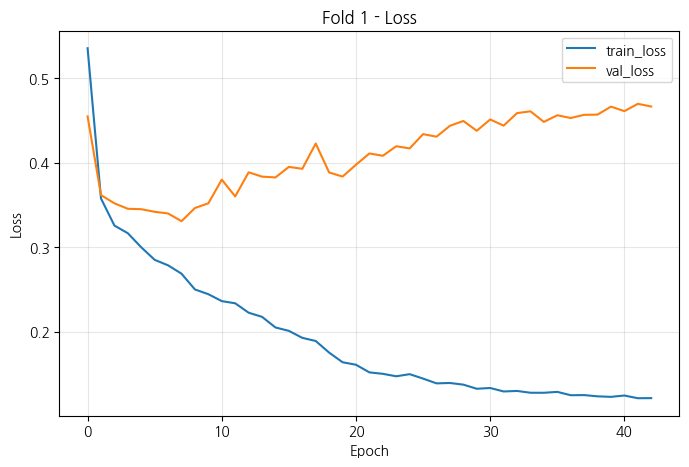

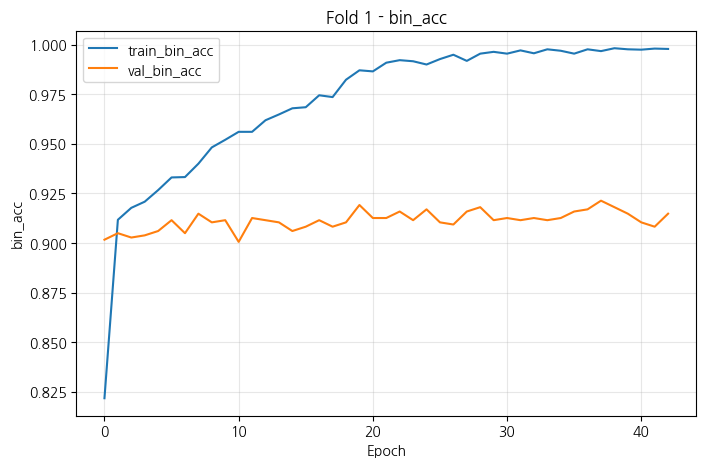

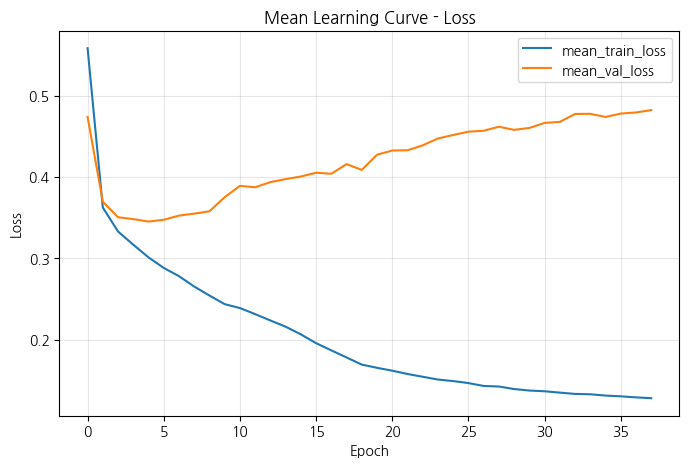

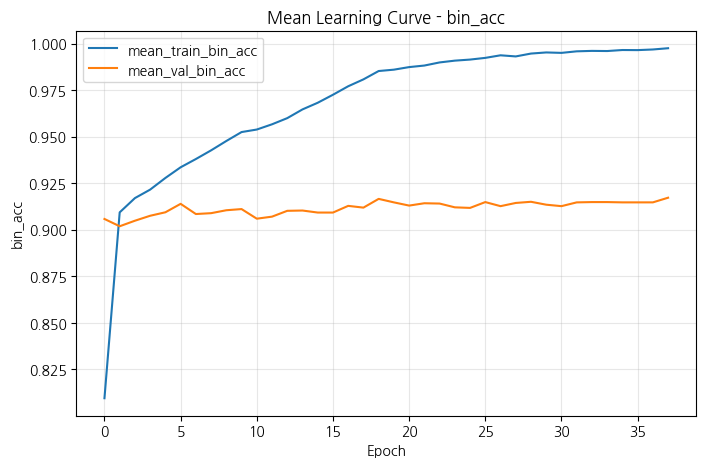

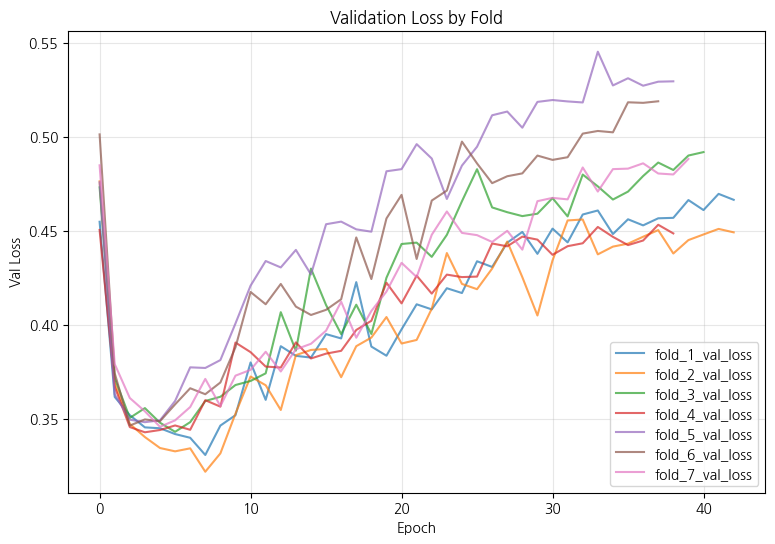

In [6]:
# 첫 번째 fold 학습 곡선 보기
plot_single_fold_history(histories[0], fold_idx=1)

# 평균 학습 곡선 보기
plot_mean_history(histories)

# 모든 fold의 validation loss 비교
plot_all_folds_loss(histories)

# 적용 내용
- 모델 크기 축소
- L2 정규화 강화
- EarlyStopping patience 축소
- ReduceLROnPlateau 더 빠르게 적용
- K-Fold 학습 중 history 저장
- 평균 학습곡선 시각화
- OOF 기반 cutoff 최적화


# Feature Engineering

기본 피처 외에도 와인 품질과 관련 있을 수 있는 비율값 및 상호작용 변수를 추가한다.

## 추가 변수 예시
- alcohol_sugar_ratio
- density_alcohol_interaction
- total_acidity
- sulfur_ratio
- sulphates_chlorides_ratio
- citric_fixed_ratio
- alcohol_sulphates_interaction
- acidity_ph_interaction

In [9]:
def add_features(dataframe):
    df_ = dataframe.copy()

    if {'alcohol', 'residual sugar'}.issubset(df_.columns):
        df_['alcohol_sugar_ratio'] = df_['alcohol'] / (df_['residual sugar'] + 1.0)

    if {'density', 'alcohol'}.issubset(df_.columns):
        df_['density_alcohol_interaction'] = df_['density'] * df_['alcohol']

    if {'fixed acidity', 'volatile acidity', 'citric acid'}.issubset(df_.columns):
        df_['total_acidity'] = (
            df_['fixed acidity'] + df_['volatile acidity'] + df_['citric acid']
        )

    if {'free sulfur dioxide', 'total sulfur dioxide'}.issubset(df_.columns):
        df_['sulfur_ratio'] = df_['free sulfur dioxide'] / (df_['total sulfur dioxide'] + 1.0)

    if {'sulphates', 'chlorides'}.issubset(df_.columns):
        df_['sulphates_chlorides_ratio'] = df_['sulphates'] / (df_['chlorides'] + 1e-6)

    if {'citric acid', 'fixed acidity'}.issubset(df_.columns):
        df_['citric_fixed_ratio'] = df_['citric acid'] / (df_['fixed acidity'] + 1e-6)

    if {'alcohol', 'sulphates'}.issubset(df_.columns):
        df_['alcohol_sulphates_interaction'] = df_['alcohol'] * df_['sulphates']

    if {'pH', 'fixed acidity'}.issubset(df_.columns):
        df_['acidity_ph_interaction'] = df_['fixed acidity'] / (df_['pH'] + 1e-6)

    return df_

df = add_features(df)

X = df.drop(columns=["quality"]).copy()
y = df["quality"].astype(int).values

classes = np.sort(np.unique(y))
n_classes = len(classes)
n_outputs = n_classes - 1

print("클래스:", classes)
print("입력 피처 수:", X.shape[1])
print("Ordinal output 수:", n_outputs)

클래스: [3 4 5 6 7 8]
입력 피처 수: 19
Ordinal output 수: 5


# Ordinal Target 생성

순서형 분류에서는 하나의 softmax 출력 대신,  
각 샘플이 특정 품질 등급보다 큰지 여부를 여러 개의 이진 출력으로 변환한다.

예를 들어 클래스가 `[3, 4, 5, 6, 7, 8]` 일 때:

- y = 6 이면 `[1, 1, 1, 0, 0]`
- 의미: 3보다 큼, 4보다 큼, 5보다 큼, 6보다 크지 않음, 7보다 크지 않음

In [10]:
def to_ordinal_targets(y_int, classes):
    thresholds = classes[:-1]
    return (y_int[:, None] > thresholds[None, :]).astype(np.float32)

# Train/Test Split 및 Scaling

데이터를 train/test로 분할한 뒤,  
StandardScaler를 이용해 입력값을 표준화한다.

주의할 점은 scaler는 반드시 train 데이터에만 fit해야 한다.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

print("Train shape:", X_train_scaled.shape, y_train.shape)
print("Test shape :", X_test_scaled.shape, y_test.shape)

Train shape: (1279, 19) (1279,)
Test shape : (320, 19) (320,)


# Ordinal Classification 모델 정의

이전 실험에서 validation loss가 빠르게 상승하는 과적합 패턴이 관찰되었으므로,  
이번에는 다음과 같은 방향으로 모델을 조정한다.

## 조정 내용
- 첫 Dense 층 크기를 256에서 128로 축소
- residual block 수를 줄여 모델 복잡도 감소
- L2 정규화 강화
- dropout은 지나치게 크지 않게 조정
- learning rate를 약간 낮춤

이 구조는 작은 tabular 데이터에서 과적합을 줄이기 위한 목적을 가진다.

In [12]:
def residual_block(x, units, dropout_rate=0.08, l2_reg=3e-4):
    shortcut = x

    if int(x.shape[-1]) != units:
        shortcut = Dense(units, kernel_regularizer=l2(l2_reg))(shortcut)
        shortcut = BatchNormalization()(shortcut)

    out = Dense(units, activation='relu', kernel_regularizer=l2(l2_reg))(x)
    out = BatchNormalization()(out)
    out = Dropout(dropout_rate)(out)

    out = Dense(units, kernel_regularizer=l2(l2_reg))(out)
    out = BatchNormalization()(out)

    out = Add()([shortcut, out])
    out = Activation('relu')(out)
    return out


def build_ordinal_model(input_dim, n_outputs):
    inputs = Input(shape=(input_dim,))

    x = Dense(128, activation='relu', kernel_regularizer=l2(3e-4))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.10)(x)

    x = residual_block(x, 128, dropout_rate=0.08, l2_reg=3e-4)

    x = Dense(64, activation='relu', kernel_regularizer=l2(3e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.08)(x)

    x = Dense(32, activation='relu', kernel_regularizer=l2(3e-4))(x)
    x = Dropout(0.05)(x)

    outputs = Dense(n_outputs, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.BinaryAccuracy(name="bin_acc")]
    )
    return model

# 예측 후처리 함수

Ordinal classification의 출력은 각 threshold를 넘을 확률 형태로 나온다.  
이 값은 이론상 단조 감소 형태를 가져야 하지만 실제 예측에서는 깨질 수 있다.

따라서 다음 두 가지 후처리를 적용한다.

1. monotonicity 보정
2. cutoff 기준으로 최종 클래스 변환

In [13]:
def enforce_monotonicity(probs):
    return np.minimum.accumulate(probs, axis=1)

def ordinal_probs_to_class(probs, classes, cutoffs=None):
    probs = enforce_monotonicity(probs)

    if cutoffs is None:
        cutoffs = np.full(probs.shape[1], 0.5, dtype=np.float32)
    else:
        cutoffs = np.array(cutoffs, dtype=np.float32)

    count = (probs > cutoffs[None, :]).sum(axis=1)
    return classes[count]

# Stratified K-Fold 학습

이번 실험에서는 Stratified K-Fold를 사용하여
각 fold별 validation 성능을 안정적으로 평가한다.

또한 다음을 함께 수행한다.

- history 저장
- sample weight 적용
- early stopping 더 빠르게 적용
- fold별 validation accuracy 기록
- test set 예측값 앙상블 저장

In [14]:
N_SPLITS = 7
BATCH_SIZE = 16
EPOCHS = 200

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_probs = np.zeros((len(X_train_scaled), n_outputs), dtype=np.float32)
test_probs_folds = []
fold_scores = []
histories = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train), start=1):
    print(f"\n================ Fold {fold}/{N_SPLITS} ================")

    X_tr, X_val = X_train_scaled[tr_idx], X_train_scaled[val_idx]
    y_tr_cls, y_val_cls = y_train[tr_idx], y_train[val_idx]

    y_tr_ord = to_ordinal_targets(y_tr_cls, classes)
    y_val_ord = to_ordinal_targets(y_val_cls, classes)

    cls_unique = np.unique(y_tr_cls)
    cls_weights = compute_class_weight(
        class_weight='balanced',
        classes=cls_unique,
        y=y_tr_cls
    )
    cls_weight_map = dict(zip(cls_unique, cls_weights))
    sample_weights = np.array([cls_weight_map[v] for v in y_tr_cls], dtype=np.float32)

    model = build_ordinal_model(X_train_scaled.shape[1], n_outputs)

    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=6,
            min_delta=0.001,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]

    history = model.fit(
        X_tr, y_tr_ord,
        validation_data=(X_val, y_val_ord),
        sample_weight=sample_weights,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=0
    )

    histories.append(history.history)

    val_probs = model.predict(X_val, verbose=0)
    val_pred_default = ordinal_probs_to_class(val_probs, classes, cutoffs=None)
    val_acc = accuracy_score(y_val_cls, val_pred_default)
    fold_scores.append(val_acc)

    print(f"Fold {fold} Default Accuracy: {val_acc:.4f}")

    oof_probs[val_idx] = val_probs

    test_probs = model.predict(X_test_scaled, verbose=0)
    test_probs_folds.append(test_probs)


================ Fold 1/7 ================


I0000 00:00:1774578179.981610   21634 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_352880__.45
I0000 00:00:1774578184.283395   21631 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_352880__.45



Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 21: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 29: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 31: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 33: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.
Epoch 33: early stopping
Restoring model weights from the end of the best epoch: 27.
Fold 1 Default Accuracy: 0.4481

================ Fold 2/7 ================


I0000 00:00:1774578203.393371   21635 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_371463__.45
I0000 00:00:1774578205.906345   21635 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_371463__.45



Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 32: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 34: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
Epoch 34: early stopping
Restoring model weights from the end of the best epoch: 28.
Fold 2 Default Accuracy: 0.5792

================ Fold 3/7 ================


...


Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 30: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 32: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 34: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
Epoch 34: early stopping
Restoring model weights from the end of the best epoch: 28.
Fold 5 Default Accuracy: 0.5628

================ Fold 6/7 ================


I0000 00:00:1774578270.612763   21632 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_445566__.45
I0000 00:00:1774578273.151499   21633 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_445566__.45



Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 20: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 22: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 24: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 18.
Fold 6 Default Accuracy: 0.5275

================ Fold 7/7 ================


I0000 00:00:1774578288.047099   21630 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_460718__.45
I0000 00:00:1774578290.568102   21631 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_460718__.45



Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 26: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 28: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
Epoch 28: early stopping
Restoring model weights from the end of the best epoch: 22.
Fold 7 Default Accuracy: 0.5110


# 기본 성능 평가

OOF 예측과 test 앙상블 예측을 이용해 기본 성능을 확인한다.  
이 단계에서는 cutoff를 모두 0.5로 둔 상태의 결과를 본다.

In [15]:
oof_pred_default = ordinal_probs_to_class(oof_probs, classes, cutoffs=None)
oof_acc_default = accuracy_score(y_train, oof_pred_default)

test_probs_mean = np.mean(test_probs_folds, axis=0)
test_pred_default = ordinal_probs_to_class(test_probs_mean, classes, cutoffs=None)
test_acc_default = accuracy_score(y_test, test_pred_default)

print("\n======================================")
print("Fold Accuracy 목록:", [round(x, 4) for x in fold_scores])
print("Mean Fold Accuracy:", round(np.mean(fold_scores), 4))
print("Default OOF Accuracy :", round(oof_acc_default, 4))
print("Default Test Accuracy:", round(test_acc_default, 4))
print("======================================")


Fold Accuracy 목록: [0.4481, 0.5792, 0.5574, 0.5847, 0.5628, 0.5275, 0.511]
Mean Fold Accuracy: 0.5387
Default OOF Accuracy : 0.5387
Default Test Accuracy: 0.5906


# Cutoff 최적화

Ordinal 출력은 각 threshold별 확률을 내놓는다.  
기본적으로는 0.5를 기준으로 클래스를 나누지만, 실제 데이터에서는 이 경계가 최적이 아닐 수 있다.

따라서 OOF 예측값을 기반으로 각 threshold에 대한 최적 cutoff를 탐색한다.

In [16]:
def optimize_cutoffs_coordinate_descent(oof_probs, y_true, classes, rounds=6, grid_size=41):
    cutoffs = np.full(oof_probs.shape[1], 0.5, dtype=np.float32)
    grid = np.linspace(0.20, 0.80, grid_size)

    best_acc = accuracy_score(y_true, ordinal_probs_to_class(oof_probs, classes, cutoffs))

    for r in range(rounds):
        improved = False

        for j in range(len(cutoffs)):
            local_best_cut = cutoffs[j]
            local_best_acc = best_acc

            for c in grid:
                trial = cutoffs.copy()
                trial[j] = c
                pred = ordinal_probs_to_class(oof_probs, classes, trial)
                acc = accuracy_score(y_true, pred)

                if acc > local_best_acc:
                    local_best_acc = acc
                    local_best_cut = c

            if local_best_acc > best_acc:
                cutoffs[j] = local_best_cut
                best_acc = local_best_acc
                improved = True

        print(f"round {r+1}: best_acc={best_acc:.4f}, cutoffs={np.round(cutoffs, 3)}")

        if not improved:
            break

    return cutoffs, best_acc

best_cutoffs, best_oof_acc = optimize_cutoffs_coordinate_descent(
    oof_probs=oof_probs,
    y_true=y_train,
    classes=classes,
    rounds=8,
    grid_size=51
)

print("\nOptimized cutoffs:", np.round(best_cutoffs, 4))
print("Optimized OOF Accuracy:", round(best_oof_acc, 4))

round 1: best_acc=0.5958, cutoffs=[0.5   0.2   0.524 0.788 0.536]
round 2: best_acc=0.5958, cutoffs=[0.5   0.2   0.524 0.788 0.536]

Optimized cutoffs: [0.5   0.2   0.524 0.788 0.536]
Optimized OOF Accuracy: 0.5958


# 최종 Test 평가

최적화된 cutoff를 적용한 뒤 최종 test 성능을 확인한다.  
confusion matrix와 classification report도 함께 출력한다.

In [17]:
test_pred_opt = ordinal_probs_to_class(test_probs_mean, classes, best_cutoffs)
test_acc_opt = accuracy_score(y_test, test_pred_opt)

print("\n======================================")
print("Optimized Test Accuracy:", round(test_acc_opt, 4))
print("======================================")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred_opt))

print("\nClassification Report:")
print(classification_report(y_test, test_pred_opt, digits=4))

within_1 = np.mean(np.abs(test_pred_opt - y_test) <= 1)
print("±1 허용 정확도:", round(within_1, 4))


Optimized Test Accuracy: 0.6156

Confusion Matrix:
[[  0   0   2   0   0   0]
 [  0   2   9   0   0   0]
 [  0   2 100  34   0   0]
 [  0   0  40  82   6   0]
 [  0   0   2  23  13   2]
 [  0   0   0   2   1   0]]

Classification Report:
              precision    recall  f1-score   support

           3     0.0000    0.0000    0.0000         2
           4     0.5000    0.1818    0.2667        11
           5     0.6536    0.7353    0.6920       136
           6     0.5816    0.6406    0.6097       128
           7     0.6500    0.3250    0.4333        40
           8     0.0000    0.0000    0.0000         3

    accuracy                         0.6156       320
   macro avg     0.3975    0.3138    0.3336       320
weighted avg     0.6088    0.6156    0.6013       320

±1 허용 정확도: 0.9812


# 학습곡선 시각화

K-Fold 학습 중 저장한 history를 이용해 평균 학습곡선을 시각화한다.

## 확인 포인트
- train loss는 계속 감소하는가
- validation loss는 어느 epoch에서 최저점을 찍는가
- 과적합이 시작되는 시점은 언제인가

In [18]:
def plot_mean_history(histories):
    if len(histories) == 0:
        print("histories가 비어 있습니다.")
        return

    min_epochs = min(len(h['loss']) for h in histories)

    train_loss = np.mean([h['loss'][:min_epochs] for h in histories], axis=0)
    val_loss = np.mean([h['val_loss'][:min_epochs] for h in histories], axis=0)

    best_epoch = int(np.argmin(val_loss))
    best_val = val_loss[best_epoch]

    plt.figure(figsize=(8, 5))
    plt.plot(train_loss, label='mean_train_loss')
    plt.plot(val_loss, label='mean_val_loss')
    plt.axvline(best_epoch, linestyle='--', label=f'best_epoch={best_epoch}')
    plt.scatter(best_epoch, best_val, s=50, label=f'best_val_loss={best_val:.4f}')
    plt.title('Mean Learning Curve - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"best epoch: {best_epoch}")
    print(f"best val loss: {best_val:.4f}")


def plot_mean_metric(histories, metric_name='bin_acc'):
    if len(histories) == 0:
        print("histories가 비어 있습니다.")
        return

    val_metric_name = f'val_{metric_name}'
    if metric_name not in histories[0] or val_metric_name not in histories[0]:
        print(f"{metric_name} 또는 {val_metric_name}가 history에 없습니다.")
        return

    min_epochs = min(len(h[metric_name]) for h in histories)

    train_metric = np.mean([h[metric_name][:min_epochs] for h in histories], axis=0)
    val_metric = np.mean([h[val_metric_name][:min_epochs] for h in histories], axis=0)

    best_epoch = int(np.argmax(val_metric))
    best_val = val_metric[best_epoch]

    plt.figure(figsize=(8, 5))
    plt.plot(train_metric, label=f'mean_train_{metric_name}')
    plt.plot(val_metric, label=f'mean_val_{metric_name}')
    plt.axvline(best_epoch, linestyle='--', label=f'best_epoch={best_epoch}')
    plt.scatter(best_epoch, best_val, s=50, label=f'best_val_{metric_name}={best_val:.4f}')
    plt.title(f'Mean Learning Curve - {metric_name}')
    plt.xlabel('Epoch')
    plt.ylabel(metric_name)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"best epoch: {best_epoch}")
    print(f"best val {metric_name}: {best_val:.4f}")


def plot_all_folds_val_loss(histories):
    if len(histories) == 0:
        print("histories가 비어 있습니다.")
        return

    plt.figure(figsize=(9, 6))
    for i, h in enumerate(histories, start=1):
        plt.plot(h['val_loss'], alpha=0.7, label=f'fold_{i}_val_loss')
    plt.title('Validation Loss by Fold')
    plt.xlabel('Epoch')
    plt.ylabel('Val Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

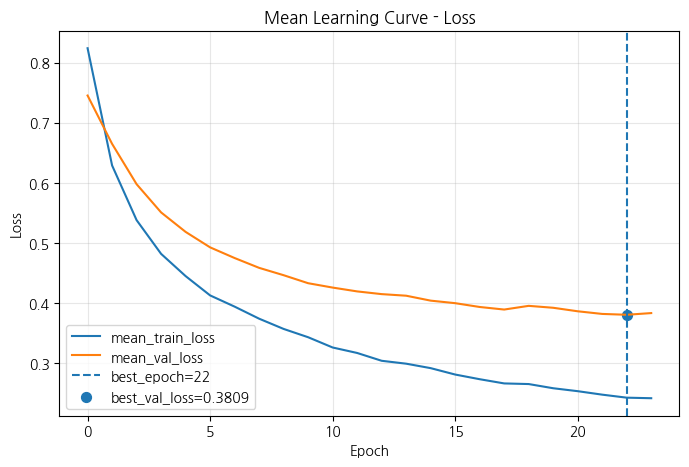

best epoch: 22
best val loss: 0.3809


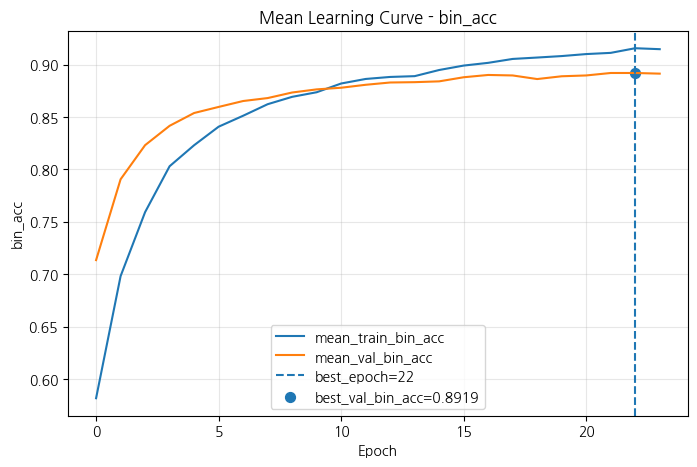

best epoch: 22
best val bin_acc: 0.8919


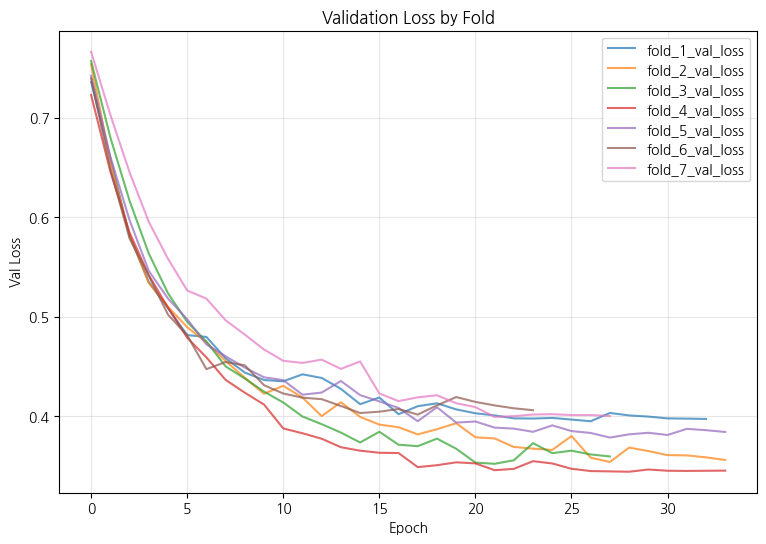

In [19]:
plot_mean_history(histories)
plot_mean_metric(histories, metric_name='bin_acc')
plot_all_folds_val_loss(histories)

In [20]:
test_probs_mon = enforce_monotonicity(test_probs_mean)

print("\n예측 샘플 10개")
for i in range(min(10, len(y_test))):
    print(
        f"[{i}] 실제={y_test[i]} | "
        f"ordinal_probs={np.round(test_probs_mon[i], 3)} | "
        f"default={test_pred_default[i]} | "
        f"optimized={test_pred_opt[i]}"
    )


예측 샘플 10개
[0] 실제=6 | ordinal_probs=[0.998 0.993 0.976 0.791 0.323] | default=7 | optimized=7
[1] 실제=5 | ordinal_probs=[0.969 0.879 0.473 0.043 0.012] | default=5 | optimized=5
[2] 실제=5 | ordinal_probs=[0.95  0.737 0.2   0.027 0.008] | default=5 | optimized=5
[3] 실제=5 | ordinal_probs=[0.987 0.924 0.744 0.198 0.02 ] | default=6 | optimized=6
[4] 실제=6 | ordinal_probs=[0.99  0.915 0.4   0.065 0.012] | default=5 | optimized=5
[5] 실제=6 | ordinal_probs=[0.993 0.978 0.925 0.52  0.025] | default=7 | optimized=6
[6] 실제=5 | ordinal_probs=[0.976 0.907 0.271 0.025 0.021] | default=5 | optimized=5
[7] 실제=4 | ordinal_probs=[0.792 0.268 0.031 0.003 0.003] | default=4 | optimized=5
[8] 실제=6 | ordinal_probs=[0.976 0.962 0.428 0.095 0.025] | default=5 | optimized=5
[9] 실제=8 | ordinal_probs=[0.996 0.994 0.967 0.752 0.21 ] | default=7 | optimized=6


# 하이퍼 파라미터 튜닝

In [21]:
def residual_block(x, units, dropout_rate=0.08, l2_reg=1e-4):
    shortcut = x

    if int(x.shape[-1]) != units:
        shortcut = Dense(units, kernel_regularizer=l2(l2_reg))(shortcut)
        shortcut = BatchNormalization()(shortcut)

    out = Dense(units, activation='relu', kernel_regularizer=l2(l2_reg))(x)
    out = BatchNormalization()(out)
    out = Dropout(dropout_rate)(out)

    out = Dense(units, kernel_regularizer=l2(l2_reg))(out)
    out = BatchNormalization()(out)

    out = Add()([shortcut, out])
    out = Activation('relu')(out)
    return out


def build_regression_model(input_dim, trial):
    units1 = trial.suggest_categorical("units1", [64, 96, 128, 160])
    units2 = trial.suggest_categorical("units2", [32, 64, 96, 128])
    use_residual = trial.suggest_categorical("use_residual", [True, False])

    dropout1 = trial.suggest_float("dropout1", 0.03, 0.15)
    dropout2 = trial.suggest_float("dropout2", 0.03, 0.12)
    l2_reg = trial.suggest_float("l2_reg", 1e-5, 1e-3, log=True)
    lr = trial.suggest_float("learning_rate", 3e-4, 1e-3, log=True)

    inputs = Input(shape=(input_dim,))

    x = Dense(units1, activation='relu', kernel_regularizer=l2(l2_reg))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(dropout1)(x)

    if use_residual:
        x = residual_block(x, units1, dropout_rate=dropout1, l2_reg=l2_reg)

    x = Dense(units2, activation='relu', kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout2)(x)

    x = Dense(32, activation='relu', kernel_regularizer=l2(l2_reg))(x)
    x = Dropout(0.03)(x)

    outputs = Dense(1, activation='linear')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=['mae']
    )
    return model

In [31]:
def objective(trial):
    from sklearn.model_selection import KFold

    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    min_quality = int(np.min(y_train))
    max_quality = int(np.max(y_train))

    kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
    fold_scores = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_scaled), start=1):
        X_tr, X_val = X_train_scaled[tr_idx], X_train_scaled[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]

        model = build_regression_model(X_train_scaled.shape[1], trial)

        callbacks = [
            EarlyStopping(
                monitor='val_loss',
                patience=6,
                min_delta=0.001,
                restore_best_weights=True,
                verbose=0
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=2,
                min_lr=1e-6,
                verbose=0
            )
        ]

        model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=120,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=0
        )

        val_pred_cont = model.predict(X_val, verbose=0).reshape(-1)
        val_pred_cls = np.clip(np.rint(val_pred_cont), min_quality, max_quality).astype(int)
        val_true_cls = y_val.astype(int)

        val_acc = accuracy_score(val_true_cls, val_pred_cls)
        fold_scores.append(val_acc)

        tf.keras.backend.clear_session()

    return np.mean(fold_scores)

In [32]:

import optuna 

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25)

print("Best Score:", study.best_value)
print("Best Params:")
for k, v in study.best_params.items():
    print(f"{k}: {v}")

[I 2026-03-27 11:39:01,645] A new study created in memory with name: no-name-8153161d-437e-41d8-a23b-c827149ed4f0
I0000 00:00:1774579144.198822   21630 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_494325__.46
I0000 00:00:1774579148.559085   21631 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_494325__.46
I0000 00:00:1774579157.577859   21632 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774579161.487991   21630 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_507110__.46
I0000 00:00:1774579163.892854   21631 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_507110__.46
I0000 00:00:1774579176.862144   21630 dot_merger.cc:481] Merging Dots in computation: a_inferenc

Best Score: 0.586436887254902
Best Params:
batch_size: 32
units1: 128
units2: 96
use_residual: False
dropout1: 0.13211592586239174
dropout2: 0.05650775205528663
l2_reg: 0.0005394746049221513
learning_rate: 0.0005701457289259952


In [33]:
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.metrics import accuracy_score, mean_absolute_error
import numpy as np

def build_simple_regression_model(input_dim, units1=128, units2=96, activation='relu',
                                  dropout1=0.13, dropout2=0.06,
                                  l2_reg=5.4e-4, learning_rate=5.7e-4):
    inputs = Input(shape=(input_dim,))

    x = Dense(units1, activation=activation, kernel_regularizer=l2(l2_reg))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(dropout1)(x)

    x = Dense(units2, activation=activation, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout2)(x)

    x = Dense(32, activation=activation, kernel_regularizer=l2(l2_reg))(x)
    x = Dropout(0.03)(x)

    outputs = Dense(1, activation='linear')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=['mae']
    )
    return model


def train_and_evaluate(X_train_scaled, y_train, X_test_scaled, y_test,
                       units1, units2, activation):
    tf.keras.backend.clear_session()

    model = build_simple_regression_model(
        input_dim=X_train_scaled.shape[1],
        units1=units1,
        units2=units2,
        activation=activation
    )

    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=6,
            min_delta=0.001,
            restore_best_weights=True,
            verbose=0
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=0
        )
    ]

    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=120,
        batch_size=32,
        callbacks=callbacks,
        verbose=0
    )

    pred_cont = model.predict(X_test_scaled, verbose=0).reshape(-1)
    pred_cls = np.clip(np.rint(pred_cont), int(y_train.min()), int(y_train.max())).astype(int)
    y_test_cls = y_test.astype(int)

    acc = accuracy_score(y_test_cls, pred_cls)
    mae = mean_absolute_error(y_test, pred_cont)
    within_1 = np.mean(np.abs(pred_cls - y_test_cls) <= 1)

    return {
        'units1': units1,
        'units2': units2,
        'activation': activation,
        'accuracy': acc,
        'mae': mae,
        'within_1': within_1,
        'best_epoch': len(history.history['loss'])
    }


experiments = [
    (128, 96, 'relu'),
    (96, 64, 'relu'),
    (128, 96, 'swish'),
    (96, 64, 'swish'),
]

results = []
for units1, units2, activation in experiments:
    result = train_and_evaluate(
        X_train_scaled, y_train,
        X_test_scaled, y_test,
        units1, units2, activation
    )
    results.append(result)

for r in results:
    print(r)

I0000 00:00:1774580861.090272   21635 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2034368__.29
I0000 00:00:1774580863.233302   21630 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2034368__.29
I0000 00:00:1774580872.726477   21632 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2044093__.29
I0000 00:00:1774580872.800756   21632 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774580874.958548   21632 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2044093__.29
I0000 00:00:1774580883.806209   21635 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2053846__.32
I0000 00:00:1774580886.036682   21631 dot_merger.cc:481] Merging Dots in compu

{'units1': 128, 'units2': 96, 'activation': 'relu', 'accuracy': 0.5375, 'mae': 0.5397936105728149, 'within_1': np.float64(0.96875), 'best_epoch': 29}
{'units1': 96, 'units2': 64, 'activation': 'relu', 'accuracy': 0.571875, 'mae': 0.5243690013885498, 'within_1': np.float64(0.978125), 'best_epoch': 28}
{'units1': 128, 'units2': 96, 'activation': 'swish', 'accuracy': 0.5875, 'mae': 0.501028835773468, 'within_1': np.float64(0.978125), 'best_epoch': 20}
{'units1': 96, 'units2': 64, 'activation': 'swish', 'accuracy': 0.596875, 'mae': 0.5145637392997742, 'within_1': np.float64(0.975), 'best_epoch': 25}


In [34]:
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

def build_best_regression_model(input_dim):
    inputs = Input(shape=(input_dim,))

    x = Dense(96, activation='swish', kernel_regularizer=l2(5.4e-4))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.13)(x)

    x = Dense(64, activation='swish', kernel_regularizer=l2(5.4e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.056)(x)

    x = Dense(32, activation='swish', kernel_regularizer=l2(5.4e-4))(x)
    x = Dropout(0.03)(x)

    outputs = Dense(1, activation='linear')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5.7e-4),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=['mae']
    )
    return model

model = build_best_regression_model(X_train_scaled.shape[1])

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=6,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=120,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/120


I0000 00:00:1774581000.413199   21630 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2071082__.32


28/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.4646 - mae: 4.8828

I0000 00:00:1774581002.283162   21631 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2071082__.32


32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 3.9393 - mae: 4.3545 - val_loss: 4.8057 - val_mae: 5.2239 - learning_rate: 5.7000e-04
Epoch 2/120
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2747 - mae: 2.6663 - val_loss: 4.0209 - val_mae: 4.4378 - learning_rate: 5.7000e-04
Epoch 3/120
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2303 - mae: 1.5866 - val_loss: 3.0383 - val_mae: 3.4530 - learning_rate: 5.7000e-04
Epoch 4/120
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7914 - mae: 1.1108 - val_loss: 2.1913 - val_mae: 2.6030 - learning_rate: 5.7000e-04
Epoch 5/120
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6214 - mae: 0.9256 - val_loss: 1.5611 - val_mae: 1.9652 - learning_rate: 5.7000e-04
Epoch 6/120
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5503 - mae: 0.8402 - val_loss: 1.0967 - val_mae: 1.4791 - learning_rate: 5.7000e-04
Epoch 7/120
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4820 - mae: 0.7647 - val_loss: 0.7800 - val_mae: 1.1303 - learning_rate: 5.7000e

# 추가 구조 비교 실험

이전 실험 결과, 다음 두 가지 경향이 확인되었다.

1. 은닉층 크기를 줄였을 때 성능이 개선되었다.
2. 활성화 함수는 ReLU보다 Swish가 더 우수한 결과를 보였다.

따라서 이번 실험에서는 현재 가장 유망한 구조를 기준으로,
더 작은 구조와 다른 활성화 함수 조합을 추가 비교한다.

## 비교 대상
- 96-64-32 + swish
- 80-48-24 + swish
- 96-64-32 + gelu

## 평가 기준
- Accuracy
- MAE
- ±1 허용 정확도

In [35]:
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.metrics import accuracy_score, mean_absolute_error
import numpy as np

def build_regression_model_variant(
    input_dim,
    units=(96, 64, 32),
    activation='swish',
    dropout_rates=(0.13, 0.056, 0.03),
    l2_reg=5.4e-4,
    learning_rate=5.7e-4
):
    inputs = Input(shape=(input_dim,))

    x = Dense(units[0], activation=activation, kernel_regularizer=l2(l2_reg))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rates[0])(x)

    x = Dense(units[1], activation=activation, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rates[1])(x)

    x = Dense(units[2], activation=activation, kernel_regularizer=l2(l2_reg))(x)
    x = Dropout(dropout_rates[2])(x)

    outputs = Dense(1, activation='linear')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=['mae']
    )
    return model

In [36]:
def train_and_evaluate_variant(
    X_train_scaled, y_train,
    X_test_scaled, y_test,
    units=(96, 64, 32),
    activation='swish',
    dropout_rates=(0.13, 0.056, 0.03),
    l2_reg=5.4e-4,
    learning_rate=5.7e-4,
    batch_size=32
):
    tf.keras.backend.clear_session()

    model = build_regression_model_variant(
        input_dim=X_train_scaled.shape[1],
        units=units,
        activation=activation,
        dropout_rates=dropout_rates,
        l2_reg=l2_reg,
        learning_rate=learning_rate
    )

    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=6,
            min_delta=0.001,
            restore_best_weights=True,
            verbose=0
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=0
        )
    ]

    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=120,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=0
    )

    pred_cont = model.predict(X_test_scaled, verbose=0).reshape(-1)
    pred_cls = np.clip(np.rint(pred_cont), int(y_train.min()), int(y_train.max())).astype(int)
    y_test_cls = y_test.astype(int)

    acc = accuracy_score(y_test_cls, pred_cls)
    mae = mean_absolute_error(y_test, pred_cont)
    within_1 = np.mean(np.abs(pred_cls - y_test_cls) <= 1)

    return {
        'units': units,
        'activation': activation,
        'accuracy': acc,
        'mae': mae,
        'within_1': within_1,
        'best_epoch': len(history.history['loss']),
        'history': history.history
    }

# 후보 모델 비교 실행

현재 가장 유망한 `96-64-32 + swish`를 기준으로,
더 작은 구조와 다른 활성화 함수 조합을 비교한다.

In [37]:
experiments = [
    {'units': (96, 64, 32), 'activation': 'swish'},
    {'units': (80, 48, 24), 'activation': 'swish'},
    {'units': (96, 64, 32), 'activation': 'gelu'},
]

results = []

for exp in experiments:
    result = train_and_evaluate_variant(
        X_train_scaled, y_train,
        X_test_scaled, y_test,
        units=exp['units'],
        activation=exp['activation']
    )
    results.append(result)

for r in results:
    print({
        'units': r['units'],
        'activation': r['activation'],
        'accuracy': r['accuracy'],
        'mae': r['mae'],
        'within_1': r['within_1'],
        'best_epoch': r['best_epoch']
    })

I0000 00:00:1774581204.616365   21630 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2080343__.32
I0000 00:00:1774581206.623312   21631 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2080343__.32
I0000 00:00:1774581216.580209   21634 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2090499__.32
I0000 00:00:1774581216.718913   21634 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774581217.225448   21634 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774581217.742444   21634 dot_search_spa

{'units': (96, 64, 32), 'activation': 'swish', 'accuracy': 0.59375, 'mae': 0.501922607421875, 'within_1': np.float64(0.9625), 'best_epoch': 30}
{'units': (80, 48, 24), 'activation': 'swish', 'accuracy': 0.534375, 'mae': 0.5596140623092651, 'within_1': np.float64(0.959375), 'best_epoch': 22}
{'units': (96, 64, 32), 'activation': 'gelu', 'accuracy': 0.565625, 'mae': 0.5265973806381226, 'within_1': np.float64(0.96875), 'best_epoch': 23}


In [38]:
import pandas as pd

result_df = pd.DataFrame([
    {
        'units': str(r['units']),
        'activation': r['activation'],
        'accuracy': round(r['accuracy'], 4),
        'mae': round(r['mae'], 4),
        'within_1': round(float(r['within_1']), 4),
        'best_epoch': r['best_epoch']
    }
    for r in results
])

result_df.sort_values(by='accuracy', ascending=False)

,units,activation,accuracy,mae,within_1,best_epoch
0,"(96, 64, 32)",swish,0.5938,0.5019,0.9625,30
2,"(96, 64, 32)",gelu,0.5656,0.5266,0.9688,23
1,"(80, 48, 24)",swish,0.5344,0.5596,0.9594,22


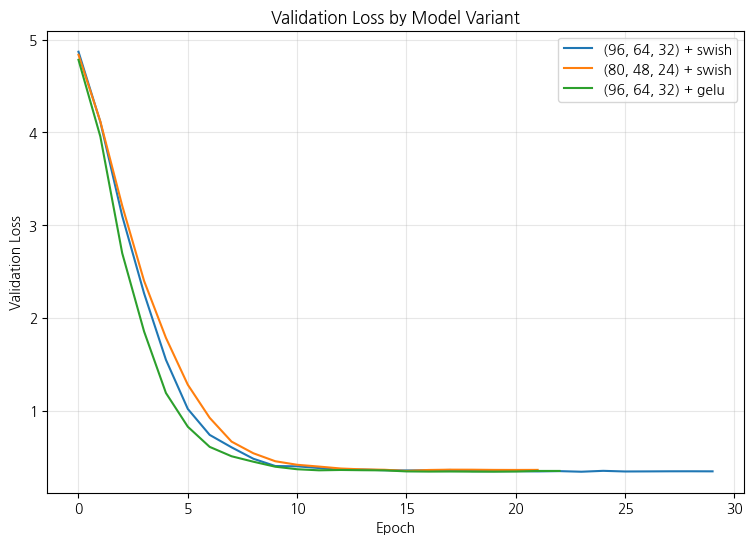

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

for r in results:
    plt.plot(
        r['history']['val_loss'],
        label=f"{r['units']} + {r['activation']}"
    )

plt.title("Validation Loss by Model Variant")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# SMOTE 증강

In [2]:
# 설치
!pip install -q imbalanced-learn

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [5]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv', sep=';')
# df 안에 quality 컬럼이 있다고 가정
X = df.drop(columns=["quality"]).copy()
y = df["quality"].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("[원본 train 분포]")
print(y_train.value_counts().sort_index())

[원본 train 분포]
quality
3      8
4     42
5    545
6    510
7    159
8     15
Name: count, dtype: int64


In [6]:
# 클래스가 적은 구간(3,4,7,8)을 부풀리는 실험
# k_neighbors는 작은 클래스 개수를 고려해서 2로 안전하게 설정
smote = SMOTE(
    sampling_strategy="not majority",
    random_state=42,
    k_neighbors=2
)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n[SMOTE 후 train 분포]")
print(pd.Series(y_train_smote, name="quality").value_counts().sort_index())

dist_compare = pd.DataFrame({
    "before": y_train.value_counts().sort_index(),
    "after": pd.Series(y_train_smote).value_counts().sort_index()
}).fillna(0).astype(int)

display(dist_compare)


[SMOTE 후 train 분포]
quality
3    545
4    545
5    545
6    545
7    545
8    545
Name: count, dtype: int64


,before,after
quality,,
3,8,545
4,42,545
5,545,545
6,510,545
7,159,545
8,15,545


In [7]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

def build_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(96, activation="swish"),
        Dense(64, activation="swish"),
        Dense(32, activation="swish"),
        Dense(1)
    ])
    model.compile(
        optimizer="adam",
        loss="mae"
    )
    return model

I0000 00:00:1774582653.872010  406690 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774582654.218647  406690 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774582655.730348  406690 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [13]:
# 원본용 스케일링
scaler_base = StandardScaler()
X_train_scaled = scaler_base.fit_transform(X_train)
X_test_scaled = scaler_base.transform(X_test)

# SMOTE용 스케일링
scaler_smote = StandardScaler()
X_train_smote_scaled = scaler_smote.fit_transform(X_train_ros)
X_test_smote_scaled = scaler_smote.transform(X_test)

In [14]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

# 1) 원본 데이터 학습
base_model = build_model(X_train_scaled.shape[1])
history_base = base_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

# 2) SMOTE 데이터 학습
smote_model = build_model(X_train_smote_scaled.shape[1])
history_smote = smote_model.fit(
    X_train_smote_scaled, y_train_ros,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

I0000 00:00:1774583062.904087  407157 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_24507__.11
I0000 00:00:1774583063.568525  407157 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_24507__.11
I0000 00:00:1774583073.180772  407155 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_37168__.11
I0000 00:00:1774583073.869095  407154 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_37168__.11


In [15]:
def evaluate_quality_model(model, X_test_scaled, y_test):
    y_true = np.asarray(y_test).astype(int)
    pred = model.predict(X_test_scaled, verbose=0).flatten()

    pred_round = np.clip(np.rint(pred), y_true.min(), y_true.max()).astype(int)

    accuracy = (pred_round == y_true).mean()
    mae = np.abs(pred - y_true).mean()
    within_1 = (np.abs(pred_round - y_true) <= 1).mean()

    return {
        "accuracy": round(float(accuracy), 4),
        "mae": round(float(mae), 4),
        "within_1": round(float(within_1), 4)
    }

base_result = evaluate_quality_model(base_model, X_test_scaled, y_test)
smote_result = evaluate_quality_model(smote_model, X_test_smote_scaled, y_test)

print("[BASE ]", base_result)
print("[SMOTE]", smote_result)

[BASE ] {'accuracy': 0.6219, 'mae': 0.4928, 'within_1': 0.9781}
[SMOTE] {'accuracy': 0.0312, 'mae': 3.5095, 'within_1': 0.1219}


In [11]:
from sklearn.metrics import classification_report, confusion_matrix

pred_base = np.clip(np.rint(base_model.predict(X_test_scaled, verbose=0).flatten()), 3, 8).astype(int)
pred_smote = np.clip(np.rint(smote_model.predict(X_test_smote_scaled, verbose=0).flatten()), 3, 8).astype(int)

print("[BASE classification report]")
print(classification_report(y_test, pred_base))

print("[SMOTE classification report]")
print(classification_report(y_test, pred_smote))

[BASE classification report]
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.50      0.18      0.27        11
           5       0.67      0.73      0.70       136
           6       0.59      0.62      0.61       128
           7       0.58      0.45      0.51        40
           8       0.00      0.00      0.00         3

    accuracy                           0.62       320
   macro avg       0.39      0.33      0.35       320
weighted avg       0.61      0.62      0.61       320

[SMOTE classification report]
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.03      0.18      0.05        11
           5       0.44      0.25      0.32       136
           6       0.48      0.25      0.33       128
           7       0.32      0.17      0.23        40
           8       0.04      0.67      0.08         3

    accuracy      

/home/dmin/miniforge3/envs/dl_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dmin/miniforge3/envs/dl_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dmin/miniforge3/envs/dl_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

In [12]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(
    sampling_strategy={
        3: 30,   # 현재 개수보다 조금만
        4: 80,
        7: 220,
        8: 40
    },
    random_state=42
)

X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

In [16]:
import numpy as np
import pandas as pd

# y_train이 pandas Series라고 가정
class_counts = y_train.value_counts().sort_index()
print("[train class counts]")
print(class_counts)

max_count = class_counts.max()

# 완만한 가중치: sqrt(max_count / count)
weight_map = {
    cls: float(np.sqrt(max_count / cnt))
    for cls, cnt in class_counts.items()
}

# 너무 세지지 않게 상한선 클리핑
weight_map = {cls: min(w, 2.5) for cls, w in weight_map.items()}

print("\n[weight map]")
print(weight_map)

sample_weight_train = y_train.map(weight_map).values
print("\n[sample weight preview]")
print(sample_weight_train[:10])

[train class counts]
quality
3      8
4     42
5    545
6    510
7    159
8     15
Name: count, dtype: int64

[weight map]
{3: 2.5, 4: 2.5, 5: 1.0, 6: 1.033744383772116, 7: 1.8513975683182806, 8: 2.5}

[sample weight preview]
[1.03374438 1.         1.03374438 1.         1.03374438 1.03374438
 1.         1.         1.03374438 1.85139757]


In [17]:
from sklearn.preprocessing import StandardScaler

scaler_weighted = StandardScaler()
X_train_weighted_scaled = scaler_weighted.fit_transform(X_train)
X_test_weighted_scaled = scaler_weighted.transform(X_test)

In [18]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

def build_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(96, activation="swish"),
        Dense(64, activation="swish"),
        Dense(32, activation="swish"),
        Dense(1)
    ])
    model.compile(
        optimizer="adam",
        loss="mae"
    )
    return model

In [19]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

weighted_model = build_model(X_train_weighted_scaled.shape[1])

history_weighted = weighted_model.fit(
    X_train_weighted_scaled,
    y_train,
    sample_weight=sample_weight_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

I0000 00:00:1774583393.648459  407156 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_42540__.11
I0000 00:00:1774583394.400259  407155 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_42540__.11


In [20]:
def evaluate_quality_model(model, X_test_scaled, y_test):
    y_true = np.asarray(y_test).astype(int)
    pred = model.predict(X_test_scaled, verbose=0).flatten()

    pred_round = np.clip(np.rint(pred), y_true.min(), y_true.max()).astype(int)

    accuracy = (pred_round == y_true).mean()
    mae = np.abs(pred - y_true).mean()
    within_1 = (np.abs(pred_round - y_true) <= 1).mean()

    return {
        "accuracy": round(float(accuracy), 4),
        "mae": round(float(mae), 4),
        "within_1": round(float(within_1), 4)
    }

weighted_result = evaluate_quality_model(weighted_model, X_test_weighted_scaled, y_test)
print("[WEIGHTED]", weighted_result)

[WEIGHTED] {'accuracy': 0.5938, 'mae': 0.4994, 'within_1': 0.9781}


In [21]:
base_result = evaluate_quality_model(base_model, X_test_scaled, y_test)
weighted_result = evaluate_quality_model(weighted_model, X_test_weighted_scaled, y_test)

compare_df = pd.DataFrame([base_result, weighted_result], index=["BASE", "WEIGHTED"])
display(compare_df)

,accuracy,mae,within_1
BASE,0.6219,0.4928,0.9781
WEIGHTED,0.5938,0.4994,0.9781


In [22]:
from sklearn.metrics import classification_report, confusion_matrix

pred_base = np.clip(np.rint(base_model.predict(X_test_scaled, verbose=0).flatten()), 3, 8).astype(int)
pred_weighted = np.clip(np.rint(weighted_model.predict(X_test_weighted_scaled, verbose=0).flatten()), 3, 8).astype(int)

print("[BASE classification report]")
print(classification_report(y_test, pred_base))

print("[WEIGHTED classification report]")
print(classification_report(y_test, pred_weighted))

[BASE classification report]
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.67      0.18      0.29        11
           5       0.67      0.69      0.68       136
           6       0.57      0.66      0.62       128
           7       0.62      0.45      0.52        40
           8       0.00      0.00      0.00         3

    accuracy                           0.62       320
   macro avg       0.42      0.33      0.35       320
weighted avg       0.62      0.62      0.61       320

[WEIGHTED classification report]
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.77      0.69       136
           6       0.57      0.55      0.56       128
           7       0.64      0.35      0.45        40
           8       0.00      0.00      0.00         3

    accuracy   

/home/dmin/miniforge3/envs/dl_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dmin/miniforge3/envs/dl_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dmin/miniforge3/envs/dl_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

In [26]:
import argparse
import json
import os
import random
import warnings
from dataclasses import dataclass
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
from tensorflow.keras import layers, regularizers


DEFAULT_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "wine-quality/winequality-red.csv"
)


@dataclass(frozen=True)
class FamilySpec:
    name: str
    mode: str
    scaler: str
    seeds: tuple[int, ...]
    hidden_units: tuple[int, ...]
    dropout: tuple[float, ...]
    l2_reg: float
    learning_rate: float
    batch_size: int
    noise: float


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Deep-learning-only high-accuracy pipeline for wine quality."
    )
    parser.add_argument("--data-path", type=str, default="")
    parser.add_argument("--test-size", type=float, default=0.20)
    parser.add_argument("--folds", type=int, default=7)
    parser.add_argument("--epochs", type=int, default=180)
    parser.add_argument("--base-seed", type=int, default=42)
    parser.add_argument("--output-json", type=str, default="best_dnn_wine_quality_results.json")
    parser.add_argument("--summary-dir", type=str, default="model_summaries")
    return parser.parse_args()


def set_seed(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


def load_data(data_path: str) -> pd.DataFrame:
    if data_path and os.path.exists(data_path):
        df = pd.read_csv(data_path)
    else:
        try:
            df = pd.read_csv(DEFAULT_URL, sep=";")
        except Exception:
            if not data_path:
                raise
            df = pd.read_csv(data_path)
    df.columns = df.columns.str.strip()
    return df


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    if {"fixed acidity", "volatile acidity", "citric acid"}.issubset(out.columns):
        out["total_acidity"] = (
            out["fixed acidity"] + out["volatile acidity"] + out["citric acid"]
        )
        out["fixed_to_volatile_ratio"] = out["fixed acidity"] / (
            out["volatile acidity"] + 1e-6
        )

    if {"free sulfur dioxide", "total sulfur dioxide"}.issubset(out.columns):
        out["sulfur_ratio"] = out["free sulfur dioxide"] / (
            out["total sulfur dioxide"] + 1.0
        )
        out["bound_sulfur"] = (
            out["total sulfur dioxide"] - out["free sulfur dioxide"]
        )

    if {"alcohol", "residual sugar"}.issubset(out.columns):
        out["alcohol_sugar_ratio"] = out["alcohol"] / (out["residual sugar"] + 1.0)

    if {"density", "alcohol"}.issubset(out.columns):
        out["density_alcohol_interaction"] = out["density"] * out["alcohol"]
        out["density_inverse"] = 1.0 / (out["density"] + 1e-6)

    if {"sulphates", "chlorides"}.issubset(out.columns):
        out["sulphates_chlorides_ratio"] = out["sulphates"] / (
            out["chlorides"] + 1e-6
        )

    if {"citric acid", "fixed acidity"}.issubset(out.columns):
        out["citric_fixed_ratio"] = out["citric acid"] / (
            out["fixed acidity"] + 1e-6
        )

    if {"alcohol", "sulphates"}.issubset(out.columns):
        out["alcohol_sulphates_interaction"] = out["alcohol"] * out["sulphates"]

    if {"pH", "fixed acidity"}.issubset(out.columns):
        out["acidity_ph_interaction"] = out["fixed acidity"] / (out["pH"] + 1e-6)

    if {"volatile acidity", "citric acid"}.issubset(out.columns):
        out["volatile_citric_balance"] = out["volatile acidity"] / (
            out["citric acid"] + 1e-6
        )

    if {"chlorides", "density"}.issubset(out.columns):
        out["chlorides_density_interaction"] = out["chlorides"] * out["density"]

    return out


def to_ordinal_targets(y: np.ndarray, classes: np.ndarray) -> np.ndarray:
    thresholds = classes[:-1]
    return (y[:, None] > thresholds[None, :]).astype(np.float32)


def ordinal_probs_to_score(probs: np.ndarray, classes: np.ndarray) -> np.ndarray:
    return np.full(probs.shape[0], classes.min(), dtype=np.float32) + probs.sum(axis=1)


def softmax_probs_to_score(probs: np.ndarray, classes: np.ndarray) -> np.ndarray:
    return (probs * classes[None, :]).sum(axis=1)


def scores_to_classes(scores: np.ndarray, thresholds: np.ndarray, classes: np.ndarray) -> np.ndarray:
    ordered_thresholds = np.sort(np.asarray(thresholds, dtype=np.float32))
    idx = np.digitize(scores, ordered_thresholds)
    return classes[idx]


def optimize_score_thresholds(
    scores: np.ndarray,
    y_true: np.ndarray,
    classes: np.ndarray,
    rounds: int = 8,
    grid_size: int = 81,
) -> tuple[np.ndarray, float]:
    thresholds = np.array(
        [(classes[i] + classes[i + 1]) / 2.0 for i in range(len(classes) - 1)],
        dtype=np.float32,
    )
    search_margin = 0.75
    best_acc = accuracy_score(y_true, scores_to_classes(scores, thresholds, classes))

    for _ in range(rounds):
        improved = False
        for idx in range(len(thresholds)):
            left_limit = classes.min() - 0.5 if idx == 0 else thresholds[idx - 1] + 0.02
            right_limit = (
                classes.max() + 0.5 if idx == len(thresholds) - 1 else thresholds[idx + 1] - 0.02
            )
            low = max(left_limit, thresholds[idx] - search_margin)
            high = min(right_limit, thresholds[idx] + search_margin)
            if low >= high:
                continue

            grid = np.linspace(low, high, grid_size)
            local_best_cut = thresholds[idx]
            local_best_acc = best_acc

            for cut in grid:
                candidate = thresholds.copy()
                candidate[idx] = cut
                pred = scores_to_classes(scores, candidate, classes)
                acc = accuracy_score(y_true, pred)
                if acc > local_best_acc:
                    local_best_acc = acc
                    local_best_cut = cut

            if local_best_acc > best_acc:
                thresholds[idx] = local_best_cut
                best_acc = local_best_acc
                improved = True

        search_margin *= 0.55
        if not improved:
            break

    return np.sort(thresholds), float(best_acc)


def make_scaler(name: str):
    if name == "standard":
        return StandardScaler()
    if name == "robust":
        return RobustScaler()
    raise ValueError(f"Unsupported scaler: {name}")


def dense_block(
    x: tf.Tensor,
    units: int,
    dropout_rate: float,
    l2_reg: float,
    activation: str = "swish",
) -> tf.Tensor:
    x = layers.Dense(
        units,
        kernel_regularizer=regularizers.l2(l2_reg),
        use_bias=False,
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)
    x = layers.Dropout(dropout_rate)(x)
    return x


def build_ordinal_model(input_dim: int, n_outputs: int, spec: FamilySpec) -> keras.Model:
    inputs = keras.Input(shape=(input_dim,))
    x = layers.GaussianNoise(spec.noise)(inputs)
    shortcut = None
    for units, drop in zip(spec.hidden_units, spec.dropout):
        block = dense_block(x, units, drop, spec.l2_reg)
        if shortcut is not None and shortcut.shape[-1] == block.shape[-1]:
            x = layers.Add()([shortcut, block])
        else:
            x = block
        shortcut = x

    outputs = layers.Dense(n_outputs, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs, name=spec.name)
    model.compile(
        optimizer=keras.optimizers.AdamW(
            learning_rate=spec.learning_rate,
            weight_decay=spec.l2_reg,
        ),
        loss=keras.losses.BinaryCrossentropy(),
    )
    return model


def build_softmax_model(input_dim: int, n_classes: int, spec: FamilySpec) -> keras.Model:
    inputs = keras.Input(shape=(input_dim,))
    x = layers.GaussianNoise(spec.noise)(inputs)
    for units, drop in zip(spec.hidden_units, spec.dropout):
        x = dense_block(x, units, drop, spec.l2_reg, activation="gelu")
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name=spec.name)
    model.compile(
        optimizer=keras.optimizers.AdamW(
            learning_rate=spec.learning_rate,
            weight_decay=spec.l2_reg,
        ),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.03),
    )
    return model


def build_regression_model(input_dim: int, spec: FamilySpec) -> keras.Model:
    inputs = keras.Input(shape=(input_dim,))
    x = layers.GaussianNoise(spec.noise)(inputs)
    shortcut = None
    for units, drop in zip(spec.hidden_units, spec.dropout):
        block = dense_block(x, units, drop, spec.l2_reg)
        if shortcut is not None and shortcut.shape[-1] == block.shape[-1]:
            x = layers.Add()([shortcut, block])
        else:
            x = block
        shortcut = x

    outputs = layers.Dense(1, activation="linear")(x)
    model = keras.Model(inputs, outputs, name=spec.name)
    model.compile(
        optimizer=keras.optimizers.AdamW(
            learning_rate=spec.learning_rate,
            weight_decay=spec.l2_reg,
        ),
        loss=keras.losses.Huber(delta=0.8),
        metrics=[keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model


def build_model(spec: FamilySpec, input_dim: int, classes: np.ndarray) -> keras.Model:
    if spec.mode == "ordinal":
        return build_ordinal_model(input_dim, len(classes) - 1, spec)
    if spec.mode == "softmax":
        return build_softmax_model(input_dim, len(classes), spec)
    if spec.mode == "regression":
        return build_regression_model(input_dim, spec)
    raise ValueError(f"Unsupported mode: {spec.mode}")


def save_model_summaries(
    specs: list[FamilySpec],
    input_dim: int,
    classes: np.ndarray,
    summary_dir: str,
) -> None:
    output_dir = Path(summary_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    for spec in specs:
        tf.keras.backend.clear_session()
        model = build_model(spec, input_dim, classes)

        summary_lines = []
        model.summary(print_fn=summary_lines.append)
        summary_text = "\n".join(summary_lines)

        print(f"\n=== Model Summary: {spec.name} ===")
        print(summary_text)

        summary_path = output_dir / f"{spec.name}_summary.txt"
        summary_path.write_text(summary_text + "\n", encoding="utf-8")


def prepare_targets(spec: FamilySpec, y_train: np.ndarray, y_val: np.ndarray, classes: np.ndarray):
    if spec.mode == "ordinal":
        return to_ordinal_targets(y_train, classes), to_ordinal_targets(y_val, classes)
    if spec.mode == "softmax":
        train_idx = np.searchsorted(classes, y_train)
        val_idx = np.searchsorted(classes, y_val)
        return keras.utils.to_categorical(train_idx, len(classes)), keras.utils.to_categorical(
            val_idx, len(classes)
        )
    if spec.mode == "regression":
        return y_train.astype(np.float32), y_val.astype(np.float32)
    raise ValueError(f"Unsupported mode: {spec.mode}")


def prediction_to_score(pred: np.ndarray, spec: FamilySpec, classes: np.ndarray) -> np.ndarray:
    if spec.mode == "ordinal":
        return ordinal_probs_to_score(pred, classes)
    if spec.mode == "softmax":
        return softmax_probs_to_score(pred, classes)
    if spec.mode == "regression":
        return pred.reshape(-1)
    raise ValueError(f"Unsupported mode: {spec.mode}")


def class_sample_weights(y: np.ndarray) -> dict[int, float]:
    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y),
        y=y,
    )
    return dict(zip(np.unique(y), weights))


def fit_family(
    spec: FamilySpec,
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: np.ndarray,
    classes: np.ndarray,
    folds: int,
    epochs: int,
    base_seed: int,
) -> tuple[np.ndarray, np.ndarray]:
    scaler = make_scaler(spec.scaler)
    X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
    X_test_scaled = scaler.transform(X_test).astype(np.float32)

    oof_seed_scores = []
    test_seed_scores = []
    sample_weight_map = class_sample_weights(y_train)

    for seed_offset, local_seed in enumerate(spec.seeds):
        skf = StratifiedKFold(
            n_splits=folds,
            shuffle=True,
            random_state=base_seed + local_seed * 101,
        )

        oof_scores = np.zeros(len(X_train_scaled), dtype=np.float32)
        fold_test_scores = []

        for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train), start=1):
            seed = base_seed + local_seed * 1000 + fold_idx
            set_seed(seed)
            tf.keras.backend.clear_session()

            x_tr = X_train_scaled[tr_idx]
            x_val = X_train_scaled[val_idx]
            y_tr = y_train[tr_idx]
            y_val = y_train[val_idx]

            train_target, val_target = prepare_targets(spec, y_tr, y_val, classes)
            model = build_model(spec, X_train_scaled.shape[1], classes)

            callbacks = [
                keras.callbacks.EarlyStopping(
                    monitor="val_loss",
                    patience=12,
                    min_delta=0.0007,
                    restore_best_weights=True,
                    verbose=0,
                ),
                keras.callbacks.ReduceLROnPlateau(
                    monitor="val_loss",
                    factor=0.5,
                    patience=4,
                    min_lr=1e-6,
                    verbose=0,
                ),
            ]

            sample_weights = np.array([sample_weight_map[v] for v in y_tr], dtype=np.float32)

            model.fit(
                x_tr,
                train_target,
                validation_data=(x_val, val_target),
                sample_weight=sample_weights,
                epochs=epochs,
                batch_size=spec.batch_size,
                callbacks=callbacks,
                verbose=0,
            )

            val_pred = model.predict(x_val, verbose=0)
            test_pred = model.predict(X_test_scaled, verbose=0)

            oof_scores[val_idx] = prediction_to_score(val_pred, spec, classes)
            fold_test_scores.append(prediction_to_score(test_pred, spec, classes))

        oof_seed_scores.append(oof_scores)
        test_seed_scores.append(np.mean(fold_test_scores, axis=0))

    return (
        np.mean(oof_seed_scores, axis=0).astype(np.float32),
        np.mean(test_seed_scores, axis=0).astype(np.float32),
    )


def optimize_blend_weights(
    train_scores: dict[str, np.ndarray],
    y_true: np.ndarray,
    classes: np.ndarray,
) -> tuple[dict[str, float], np.ndarray, float]:
    names = list(train_scores.keys())
    grids = np.linspace(0.0, 1.0, 11)
    best_weights = None
    best_thresholds = None
    best_acc = -1.0

    for w0 in grids:
        for w1 in grids:
            w2 = 1.0 - w0 - w1
            if w2 < 0.0 or w2 > 1.0:
                continue

            weights = np.array([w0, w1, w2], dtype=np.float32)
            if np.isclose(weights.sum(), 0.0):
                continue

            blended = np.zeros_like(next(iter(train_scores.values())))
            for idx, name in enumerate(names):
                blended += weights[idx] * train_scores[name]

            thresholds, acc = optimize_score_thresholds(blended, y_true, classes)
            if acc > best_acc:
                best_acc = acc
                best_thresholds = thresholds
                best_weights = {name: float(weights[idx]) for idx, name in enumerate(names)}

    return best_weights, best_thresholds, best_acc


def evaluate_split(
    name: str,
    scores: np.ndarray,
    thresholds: np.ndarray,
    y_true: np.ndarray,
    classes: np.ndarray,
) -> dict:
    pred = scores_to_classes(scores, thresholds, classes)
    return {
        "name": name,
        "accuracy": float(accuracy_score(y_true, pred)),
        "within_1": float(np.mean(np.abs(pred - y_true) <= 1)),
        "confusion_matrix": confusion_matrix(y_true, pred).tolist(),
        "classification_report": classification_report(y_true, pred, digits=4),
    }


def main() -> None:
    args = parse_args()
    set_seed(args.base_seed)

    df = add_features(load_data(args.data_path))
    X = df.drop(columns=["quality"]).copy()
    y = df["quality"].astype(int).values
    classes = np.sort(np.unique(y))

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=args.test_size,
        random_state=args.base_seed,
        stratify=y,
    )
    X_train = X_train.reset_index(drop=True)
    X_test = X_test.reset_index(drop=True)

    family_specs = [
        FamilySpec(
            name="ordinal_std",
            mode="ordinal",
            scaler="standard",
            seeds=(0, 1, 2),
            hidden_units=(256, 192, 128, 64),
            dropout=(0.18, 0.14, 0.10, 0.06),
            l2_reg=3e-4,
            learning_rate=7e-4,
            batch_size=32,
            noise=0.03,
        ),
        FamilySpec(
            name="softmax_robust",
            mode="softmax",
            scaler="robust",
            seeds=(0, 1, 2),
            hidden_units=(192, 128, 96),
            dropout=(0.16, 0.10, 0.06),
            l2_reg=4e-4,
            learning_rate=8e-4,
            batch_size=32,
            noise=0.02,
        ),
        FamilySpec(
            name="regression_std",
            mode="regression",
            scaler="standard",
            seeds=(0, 1, 2),
            hidden_units=(256, 160, 96, 48),
            dropout=(0.15, 0.10, 0.08, 0.04),
            l2_reg=3e-4,
            learning_rate=6e-4,
            batch_size=32,
            noise=0.025,
        ),
    ]

    save_model_summaries(
        specs=family_specs,
        input_dim=X_train.shape[1],
        classes=classes,
        summary_dir=args.summary_dir,
    )

    train_scores = {}
    test_scores = {}
    family_metrics = []

    for spec in family_specs:
        print(f"\n=== Training family: {spec.name} ({spec.mode}) ===")
        oof_scores, holdout_scores = fit_family(
            spec=spec,
            X_train=X_train,
            X_test=X_test,
            y_train=y_train,
            classes=classes,
            folds=args.folds,
            epochs=args.epochs,
            base_seed=args.base_seed,
        )
        thresholds, train_acc = optimize_score_thresholds(oof_scores, y_train, classes)
        metric = evaluate_split(spec.name, holdout_scores, thresholds, y_test, classes)
        metric["train_oof_accuracy"] = float(train_acc)
        metric["thresholds"] = [float(x) for x in thresholds]

        train_scores[spec.name] = oof_scores
        test_scores[spec.name] = holdout_scores
        family_metrics.append(metric)

        print(
            f"{spec.name}: OOF={train_acc:.4f} | "
            f"TEST={metric['accuracy']:.4f} | "
            f"within_1={metric['within_1']:.4f}"
        )

    blend_weights, blend_thresholds, blend_oof_acc = optimize_blend_weights(
        train_scores, y_train, classes
    )
    blended_test_scores = np.zeros_like(next(iter(test_scores.values())))
    for name, weight in blend_weights.items():
        blended_test_scores += weight * test_scores[name]

    blend_metric = evaluate_split(
        "deep_blend",
        blended_test_scores,
        blend_thresholds,
        y_test,
        classes,
    )
    blend_metric["train_oof_accuracy"] = float(blend_oof_acc)
    blend_metric["thresholds"] = [float(x) for x in blend_thresholds]
    blend_metric["weights"] = blend_weights

    results = {
        "data_shape": list(df.shape),
        "train_size": int(len(X_train)),
        "test_size": int(len(X_test)),
        "classes": classes.tolist(),
        "family_results": family_metrics,
        "blend_result": blend_metric,
    }

    print("\n=== Blend Summary ===")
    print(json.dumps(blend_metric, ensure_ascii=False, indent=2))

    with open(args.output_json, "w", encoding="utf-8") as fp:
        json.dump(results, fp, ensure_ascii=False, indent=2)

    print(f"\nSaved results to {args.output_json}")


if __name__ == "__main__":
    main()


usage: ipykernel_launcher.py [-h] [--data-path DATA_PATH]
                             [--test-size TEST_SIZE] [--folds FOLDS]
                             [--epochs EPOCHS] [--base-seed BASE_SEED]
                             [--output-json OUTPUT_JSON]
                             [--summary-dir SUMMARY_DIR]
ipykernel_launcher.py: error: argument --folds: invalid int value: '/run/user/1000/jupyter/runtime/kernel-v373eb90c18fe811e7ab09917cf1cde22ec2c0720d.json'


SystemExit: 2

데이터 shape: (1599, 20)
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64
quality 범위: 3 ~ 8
X shape: (1599, 19)

================ Fold 1/7 ================

MODEL SUMMARY


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │      5,120 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │     65,792 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dropout[0][0],    │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256)       │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │     65,792 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     65,792 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256)       │          0 │ activation[0][0], │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256)       │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     32,896 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_5[0][0]   

 Total params: 315,393 (1.20 MB)

 Trainable params: 312,449 (1.19 MB)

...


Epoch 29: ReduceLROnPlateau reducing learning rate to 0.00039999998989515007.

Epoch 53: ReduceLROnPlateau reducing learning rate to 0.00019999999494757503.

Epoch 69: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-05.

Epoch 79: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 89: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
Epoch 94: early stopping
Restoring model weights from the end of the best epoch: 59.
Fold 5 Accuracy: 0.6393
Fold 5 MAE     : 0.4851

================ Fold 6/7 ================


I0000 00:00:1774591558.869479  407153 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_497015__.69
I0000 00:00:1774591561.058381  407153 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_497015__.69



Epoch 73: ReduceLROnPlateau reducing learning rate to 0.00039999998989515007.

Epoch 94: ReduceLROnPlateau reducing learning rate to 0.00019999999494757503.

Epoch 113: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-05.

Epoch 123: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 175: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 213: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.

Epoch 223: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-06.

Epoch 234: ReduceLROnPlateau reducing learning rate to 3.12499992105586e-06.

Epoch 244: ReduceLROnPlateau reducing learning rate to 1.56249996052793e-06.

Epoch 254: ReduceLROnPlateau reducing learning rate to 1e-06.
Epoch 259: early stopping
Restoring model weights from the end of the best epoch: 224.
Fold 6 Accuracy: 0.6209
Fold 6 MAE     : 0.4929

================ Fold 7/7 ================


I0000 00:00:1774591650.633079  407156 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_601676__.69
I0000 00:00:1774591652.705546  407154 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_601676__.69



Epoch 25: ReduceLROnPlateau reducing learning rate to 0.00039999998989515007.

Epoch 38: ReduceLROnPlateau reducing learning rate to 0.00019999999494757503.

Epoch 51: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-05.

Epoch 61: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 71: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
Epoch 76: early stopping
Restoring model weights from the end of the best epoch: 41.
Fold 7 Accuracy: 0.6593
Fold 7 MAE     : 0.4842

FINAL METRICS
Fold Accuracy 목록: [0.5902, 0.5792, 0.541, 0.5738, 0.6393, 0.6209, 0.6593]
Mean Fold Accuracy: 0.6005
Optimized OOF Accuracy: 0.6059
Optimized Test Accuracy: 0.6469
Test Loss (Huber): 0.1793
Test MAE: 0.4749
±1 허용 정확도: 0.975
Best thresholds: [3.6393 4.3952 5.5144 6.4655 7.6826]

Confusion Matrix:
[[  0   0   2   0   0   0]
 [  0   1   9   1   0   0]
 [  0   0 104  31   1   0]
 [  0   0  34  87   7   0]
 [  0   0   3  22  15   0]
 [  0   0   0   1   2   0]]


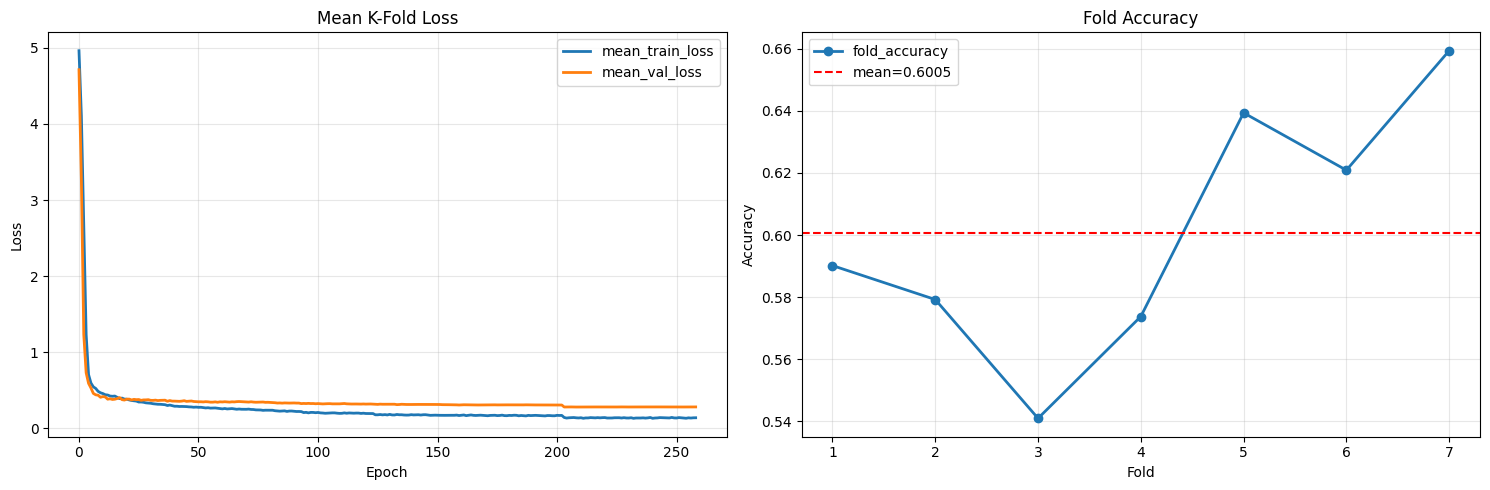

In [29]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Add, Activation
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

warnings.filterwarnings('ignore')


# =========================================================
# 0. Seed
# =========================================================
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# =========================================================
# 1. Load Data
# =========================================================
if 'redwine' in globals() and isinstance(redwine, pd.DataFrame) and 'quality' in redwine.columns:
    df_onecell = redwine.copy()
elif 'df' in globals() and isinstance(df, pd.DataFrame) and 'quality' in df.columns:
    df_onecell = df.copy()
else:
    df_onecell = pd.read_csv(
        'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv',
        sep=';'
    )

df_onecell.columns = df_onecell.columns.str.strip()


# =========================================================
# 2. Feature Engineering
# =========================================================
def add_features(dataframe):
    df_ = dataframe.copy()

    if {'alcohol', 'residual sugar'}.issubset(df_.columns):
        df_['alcohol_sugar_ratio'] = df_['alcohol'] / (df_['residual sugar'] + 1.0)

    if {'density', 'alcohol'}.issubset(df_.columns):
        df_['density_alcohol_interaction'] = df_['density'] * df_['alcohol']

    if {'fixed acidity', 'volatile acidity', 'citric acid'}.issubset(df_.columns):
        df_['total_acidity'] = (
            df_['fixed acidity'] + df_['volatile acidity'] + df_['citric acid']
        )

    if {'free sulfur dioxide', 'total sulfur dioxide'}.issubset(df_.columns):
        df_['sulfur_ratio'] = df_['free sulfur dioxide'] / (df_['total sulfur dioxide'] + 1.0)

    if {'sulphates', 'chlorides'}.issubset(df_.columns):
        df_['sulphates_chlorides_ratio'] = df_['sulphates'] / (df_['chlorides'] + 1e-6)

    if {'citric acid', 'fixed acidity'}.issubset(df_.columns):
        df_['citric_fixed_ratio'] = df_['citric acid'] / (df_['fixed acidity'] + 1e-6)

    if {'alcohol', 'sulphates'}.issubset(df_.columns):
        df_['alcohol_sulphates_interaction'] = df_['alcohol'] * df_['sulphates']

    if {'pH', 'fixed acidity'}.issubset(df_.columns):
        df_['acidity_ph_interaction'] = df_['fixed acidity'] / (df_['pH'] + 1e-6)

    return df_


df_onecell = add_features(df_onecell)
X = df_onecell.drop(columns=['quality']).copy()
y = df_onecell['quality'].astype(np.float32).values

min_quality = int(df_onecell['quality'].min())
max_quality = int(df_onecell['quality'].max())
classes = np.sort(np.unique(df_onecell['quality'].astype(int).values))

print('데이터 shape:', df_onecell.shape)
print(df_onecell['quality'].value_counts().sort_index())
print('quality 범위:', min_quality, '~', max_quality)
print('X shape:', X.shape)


# =========================================================
# 3. Split + Scale
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y.astype(int)
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)


# =========================================================
# 4. Model
# =========================================================
def residual_block(x, units, dropout_rate=0.10, l2_reg=1e-4):
    shortcut = x

    if x.shape[-1] != units:
        shortcut = Dense(units, kernel_regularizer=l2(l2_reg))(shortcut)
        shortcut = BatchNormalization()(shortcut)

    out = Dense(units, activation='relu', kernel_regularizer=l2(l2_reg))(x)
    out = BatchNormalization()(out)
    out = Dropout(dropout_rate)(out)

    out = Dense(units, kernel_regularizer=l2(l2_reg))(out)
    out = BatchNormalization()(out)

    out = Add()([shortcut, out])
    out = Activation('relu')(out)
    return out


def build_regression_model(input_dim):
    inputs = Input(shape=(input_dim,))

    x = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.15)(x)

    x = residual_block(x, 256, dropout_rate=0.10)
    x = residual_block(x, 256, dropout_rate=0.10)

    x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.10)(x)

    x = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.05)(x)

    outputs = Dense(1, activation='linear')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=8e-4),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=['mae']
    )
    return model


# =========================================================
# 5. K-Fold Training
# =========================================================
N_SPLITS = 7
EPOCHS = 400
BATCH_SIZE = 16

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_pred = np.zeros(len(X_train_scaled), dtype=np.float32)
test_pred_folds = []
fold_accs = []
fold_maes = []
histories = []
summary_printed = False

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_scaled), start=1):
    print(f'\n================ Fold {fold}/{N_SPLITS} ================')

    X_tr, X_val = X_train_scaled[tr_idx], X_train_scaled[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    tf.keras.backend.clear_session()
    model = build_regression_model(X_train_scaled.shape[1])

    if not summary_printed:
        print('\n' + '=' * 60)
        print('MODEL SUMMARY')
        print('=' * 60)
        model.summary()
        summary_printed = True

    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=35,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            min_lr=1e-6,
            verbose=1
        )
    ]

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=0
    )

    histories.append(history.history)

    val_pred = model.predict(X_val, verbose=0).flatten()
    test_pred = model.predict(X_test_scaled, verbose=0).flatten()

    oof_pred[val_idx] = val_pred
    test_pred_folds.append(test_pred)

    val_pred_round = np.clip(np.rint(val_pred), min_quality, max_quality).astype(int)
    y_val_int = y_val.astype(int)

    val_acc = accuracy_score(y_val_int, val_pred_round)
    val_mae = mean_absolute_error(y_val, val_pred)
    fold_accs.append(val_acc)
    fold_maes.append(val_mae)

    print(f'Fold {fold} Accuracy: {val_acc:.4f}')
    print(f'Fold {fold} MAE     : {val_mae:.4f}')


# =========================================================
# 6. Threshold Optimization
# =========================================================
y_train_cls = y_train.astype(int)
y_test_cls = y_test.astype(int)
test_pred_mean = np.mean(test_pred_folds, axis=0)

init_thresholds = np.array(
    [(classes[i] + classes[i + 1]) / 2 for i in range(len(classes) - 1)],
    dtype=float
)


def apply_thresholds(preds, thresholds, classes):
    thresholds = np.sort(thresholds)
    idx = np.digitize(preds, thresholds)
    return classes[idx]


def objective(thresholds):
    pred_cls = apply_thresholds(oof_pred, thresholds, classes)
    return -accuracy_score(y_train_cls, pred_cls)


result = minimize(
    objective,
    x0=init_thresholds,
    method='Nelder-Mead',
    options={'maxiter': 5000, 'disp': False}
)

best_thresholds = np.sort(result.x)
oof_pred_cls_opt = apply_thresholds(oof_pred, best_thresholds, classes)
test_pred_cls_opt = apply_thresholds(test_pred_mean, best_thresholds, classes)

oof_acc_opt = accuracy_score(y_train_cls, oof_pred_cls_opt)
test_acc_opt = accuracy_score(y_test_cls, test_pred_cls_opt)
test_mae = mean_absolute_error(y_test, test_pred_mean)
test_loss = float(tf.keras.losses.Huber(delta=1.0)(y_test, test_pred_mean).numpy())
within_1 = np.mean(np.abs(test_pred_cls_opt - y_test_cls) <= 1)

print('\n' + '=' * 60)
print('FINAL METRICS')
print('=' * 60)
print('Fold Accuracy 목록:', [round(x, 4) for x in fold_accs])
print('Mean Fold Accuracy:', round(np.mean(fold_accs), 4))
print('Optimized OOF Accuracy:', round(oof_acc_opt, 4))
print('Optimized Test Accuracy:', round(test_acc_opt, 4))
print('Test Loss (Huber):', round(test_loss, 4))
print('Test MAE:', round(test_mae, 4))
print('±1 허용 정확도:', round(within_1, 4))
print('Best thresholds:', np.round(best_thresholds, 4))

print('\nConfusion Matrix:')
print(confusion_matrix(y_test_cls, test_pred_cls_opt))

print('\nClassification Report:')
print(classification_report(y_test_cls, test_pred_cls_opt, digits=4))


# =========================================================
# 7. Plot
# =========================================================
max_len = max(len(h['loss']) for h in histories)


def pad(values, length):
    arr = np.asarray(values, dtype=np.float32)
    if len(arr) < length:
        arr = np.pad(arr, (0, length - len(arr)), constant_values=np.nan)
    return arr


mean_train_loss = np.nanmean(np.vstack([pad(h['loss'], max_len) for h in histories]), axis=0)
mean_val_loss = np.nanmean(np.vstack([pad(h['val_loss'], max_len) for h in histories]), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(mean_train_loss, label='mean_train_loss', linewidth=2)
axes[0].plot(mean_val_loss, label='mean_val_loss', linewidth=2)
axes[0].set_title('Mean K-Fold Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(range(1, N_SPLITS + 1), fold_accs, marker='o', linewidth=2, label='fold_accuracy')
axes[1].axhline(np.mean(fold_accs), color='red', linestyle='--', label=f'mean={np.mean(fold_accs):.4f}')
axes[1].set_title('Fold Accuracy')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Accuracy')
axes[1].set_xticks(range(1, N_SPLITS + 1))
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


### 마지막 코드 셀 설명

- `Seed`를 고정해서 실행할 때마다 결과가 크게 흔들리지 않도록 설정한다.
- `redwine` 또는 `df`가 이미 있으면 그 데이터를 재사용하고, 없으면 UCI `winequality-red.csv`를 바로 불러온다.
- 컬럼 이름 공백을 정리한 뒤 `quality`를 타깃으로 두고, 나머지 컬럼을 입력 피처로 사용한다.
- 단순 원본 피처만 쓰지 않고 다음과 같은 파생 피처를 추가한다.
- `alcohol_sugar_ratio`
- `density_alcohol_interaction`
- `total_acidity`
- `sulfur_ratio`
- `sulphates_chlorides_ratio`
- `citric_fixed_ratio`
- `alcohol_sulphates_interaction`
- `acidity_ph_interaction`
- 데이터를 `train/test`로 분리할 때 `quality` 분포가 유지되도록 `stratify`를 적용한다.
- `StandardScaler`로 입력값을 표준화하고, `fit`은 반드시 train 데이터에만 수행한다.
- 모델은 단순 softmax MLP가 아니라 `회귀형 DNN`으로 구성한다.
- 최종 구조는 `256 -> Residual(256) -> Residual(256) -> 128 -> 64 -> 1` 이다.
- Dropout은 순서대로 `0.15 / 0.10 / 0.10 / 0.05` 수준으로 적용한다.
- 마지막 출력은 `Dense(1)`로 두어 와인 품질을 연속값으로 예측한다.
- 손실 함수는 `Huber loss`를 사용해서 이상치에 덜 흔들리게 한다.
- 옵티마이저는 `Adam(learning_rate=8e-4)`를 사용하고, 일반화는 `Dropout + L2 regularization` 조합으로 잡는다.
- 한 번의 train/validation split 결과만 믿지 않도록 `7-Fold KFold`로 학습한다.
- 학습 파라미터는 `epochs=400`, `batch_size=16`, `EarlyStopping patience=35`, `ReduceLROnPlateau patience=10`으로 설정했다.
- 각 fold마다 다음을 수행한다.
- 모델 새로 생성
- `EarlyStopping`으로 과적합 전에 멈춤
- `ReduceLROnPlateau`로 정체 시 learning rate 감소
- validation 예측값 저장
- test 예측값 저장
- fold별 accuracy와 MAE 기록
- 첫 번째 fold에서는 `model.summary()`를 출력해서 레이어 구조와 파라미터 수를 표처럼 보여준다.
- train 전체에 대한 OOF(out-of-fold) 예측을 만든 뒤, 단순 반올림 대신 `threshold optimization`을 수행한다.
- 이 단계는 연속 예측값을 어떤 경계값으로 품질 등급 `3~8`에 나눌지 최적화하는 과정이다.
- `scipy.optimize.minimize`를 사용해서 train OOF accuracy가 가장 높아지는 threshold를 찾는다.
- 찾은 threshold를 test 예측 평균값에 적용해서 최종 분류 결과를 만든다.
- 최종 출력에서는 다음을 보여준다.
- fold accuracy 목록
- mean fold accuracy
- optimized OOF accuracy
- optimized test accuracy
- test MAE
- `±1` 허용 정확도
- best thresholds
- confusion matrix
- classification report
- 마지막 그래프는 두 개를 그린다.
- 왼쪽: K-Fold 평균 train/validation loss 곡선
- 오른쪽: fold별 accuracy와 평균 accuracy
- 즉, 이 셀은 `데이터 준비 → 피처 엔지니어링 → 모델 생성 → K-Fold 학습 → threshold 최적화 → 최종 평가 → 시각화`를 한 번에 끝내는 셀이다.
